<table align = "center" width = 100%>
   <tr>
       </td>
           </td>
       </td>
       <td>
          <div align = "center">
               <font color = "#21618C" size = 8px>
                          <b>Data Analysis on Laptop Price dataset.</b>
               </font>
          </div>
        </td>
    <tr>
</table>

**Problem Statement:- This project will help you understand how to analyze and predict laptop prices using a dataset containing laptop specifications. It is a simple regression task where we predict the price of a laptop based on its features like brand, processor, RAM, storage, etc.**

### Importing Necessary Libraries

In [1]:
# pandas library for accessing data structures which helps in loading and handling the dataset.
import pandas as pd

# Numpy library to perform certain mathematical operations and accessing numpy array
import numpy as np

# Matplotlib library for plotting graphs for analysis and visualization of the data
import matplotlib.pyplot as plt

# Seaborn library for plotting more dynamic and visually appealing graphs
import seaborn as sns

# Libraries for necessary preprocessing and preparation of the dataset
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# To Split the dataset
from sklearn.model_selection import train_test_split

# Importing the models for training
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Libraries for performing NLP tasks
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Importing the Accuracy checking metrices
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model for Hyperparameter tuning of models
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# To access 'filterwarnings' function to ignore the warnings
import warnings

In [2]:
# Setting max columns option, so that it will be able to display all the columns of the dataset
pd.set_option("display.max_columns", None)

# Setting max rows option, so that it will be able to display all the rows of the dataset
pd.set_option("display.max_rows", None)

# Step-1: Data Overview

In [ ]:
# This method is for ignoring the warnings
warnings.filterwarnings('ignore')

# loading the dataset
df_laptop_price_data = pd.read_csv("../data/laptop_prices.csv")

In [4]:
# Checking columns and rows of the dataset
No_of_rows, No_of_columns = df_laptop_price_data.shape

#Printing number of columns
print("Number of Columns:",No_of_columns)

#Printing number of rows
print("Number of Rows:",No_of_rows)

Number of Columns: 23
Number of Rows: 1275


In [5]:
df_laptop_price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

## **About the dataset (Laptop prices dataset)**
The data set contains 1275 observations. Information about the columns are given below.

#### Data Dictionary
- **`Company`**: This column represents the **name** of Laptop Manufacturer.
  
- **`Product`**: This column contains the brand & model information of the laptop.
- **`TypeName`**: Laptop Type (Notebook, Ultrabook, Gaming, etc).
- **`Inches`**: Screen Size.
- **`Ram`**: Total amount of RAM in laptop (GBs).
- **`OS`**: Operating System installed.
- **`Weight`**:  Laptop Weight in kilograms.
- **`Price_euros`**: Price of Laptop in Euros. (Target)
- **`Screen`**: Screen definition (Standard, Full HD, 4K Ultra HD, Quad HD+).
- **`ScreenW`**: Screen width (pixels).
- **`ScreenH`**: Screen height (pixels).
- **`Touchscreen`**: Whether or not the laptop has a touchscreen.
- **`IPSpanel`**: Whether or not the laptop has an IPSpanel.
- **`RetinaDisplay`**: Whether or not the laptop has retina display.
- **`CPU_company`**: Name of the company of CPU used.
- **`CPU_freq`**: Frequency of laptop CPU (Hz).
- **`CPU_model`**: Name of the CPU model used.
- **`PrimaryStorage`**: Primary storage space (GB).
- **`SecondaryStorage`**: Secondary storage space if any (GB).
- **`PrimaryStorageType`**: Primary storage type (HDD, SSD, Flash Storage, Hybrid).
- **`SecondaryStorageType`**: Secondary storage type (HDD, SSD, Hybrid, None).
- **`GPU_company`**: Name of the company of GPU used.
- **`GPU_model`**: Name of the GPU model used.

**Interpretation**

From this we can see that:
- There are **9 Numerical columns**.
- And there are **14 Object** type columns.

# Step-2: Data Preprocessing

## a) Renaming the columns

In [6]:
# Renaming the necessary columns appropriately
df_laptop_price_data = df_laptop_price_data.rename(columns = {"Inches": "Screen_Size",
                                                              "Screen": "Screen_Definition",
                                                              "TypeName": "Type_Name",
                                                              "ScreenW": "Screen_Width",
                                                              "ScreenH": "Screen_Height",
                                                              "IPSpanel": "IPS_panel",
                                                              "RetinaDisplay": "Retina_Display",
                                                              "CPU_freq": "CPU_frequency",
                                                              "PrimaryStorage": "Primary_Storage",
                                                              "SecondaryStorage": "Secondary_Storage",
                                                              "PrimaryStorageType": "Primary_Storage_Type",
                                                              "SecondaryStorageType": "Secondary_Storage_Type"})

## b) Correcting the datatypes and values according to the datatypes of the columns

In [7]:
df_laptop_price_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Company                 1275 non-null   object 
 1   Product                 1275 non-null   object 
 2   Type_Name               1275 non-null   object 
 3   Screen_Size             1275 non-null   float64
 4   Ram                     1275 non-null   int64  
 5   OS                      1275 non-null   object 
 6   Weight                  1275 non-null   float64
 7   Price_euros             1275 non-null   float64
 8   Screen_Definition       1275 non-null   object 
 9   Screen_Width            1275 non-null   int64  
 10  Screen_Height           1275 non-null   int64  
 11  Touchscreen             1275 non-null   object 
 12  IPS_panel               1275 non-null   object 
 13  Retina_Display          1275 non-null   object 
 14  CPU_company             1275 non-null   

In [8]:
df_laptop_price_data.head()

,Company,Product,Type_Name,Screen_Size,Ram,OS,Weight,Price_euros,Screen_Definition,Screen_Width,Screen_Height,Touchscreen,IPS_panel,Retina_Display,CPU_company,CPU_frequency,CPU_model,Primary_Storage,Secondary_Storage,Primary_Storage_Type,Secondary_Storage_Type,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,1600,No,Yes,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,900,No,No,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,1080,No,No,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,1800,No,Yes,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,1600,No,Yes,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [9]:
# Checking categorical columns for irregular values

#Running For loop to iterate through the categorical columns
for column in df_laptop_price_data[['Company', 'Product', 'Type_Name', 'OS', 'Screen_Definition', 'CPU_company', 'CPU_model', 'Primary_Storage_Type',
                                    'Secondary_Storage_Type', 'GPU_company', 'GPU_model']]:

    if df_laptop_price_data[column].nunique() < 20:

        # Printing the name of the column whose unique values will be now printed
        print(f"Unique values from {column} column:")
    
        # Printing the unique values from the column being iterated
        print(df_laptop_price_data[column].value_counts())
    
        # Just writing this print function to display the information well
        print()

Unique values from Company column:
Company
Dell         291
Lenovo       289
HP           268
Asus         152
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

Unique values from Type_Name column:
Type_Name
Notebook              707
Gaming                205
Ultrabook             194
2 in 1 Convertible    117
Workstation            29
Netbook                23
Name: count, dtype: int64

Unique values from OS column:
OS
Windows 10      1048
No OS             66
Linux             58
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

Unique values from Screen_Definition column:
Screen_Definition
Full HD        835
Standard       369
4K Ultra HD     43
Quad HD+

**Interpretation**

Here we can see that there are no **two or more different values** in these columns which **signifies** the same thing. Now we will check if certain columns have only one same value in all the records.

In [10]:
# Checking if columns have only one same value in them
for column in df_laptop_price_data.columns:
    if df_laptop_price_data[column].nunique() == 1:
        print(f"{column} is the column with all the values being same")
    elif df_laptop_price_data[column].nunique() == len(df_laptop_price_data):
        print(f"{column} is the column with all the values being same")

**Interpretation**

We can see here that there are no columns which has only one same value in them.

## c) Null value Handling

In [11]:
# Checking how many null values are present in the dataset
df_laptop_price_data.isnull().sum()

Company                   0
Product                   0
Type_Name                 0
Screen_Size               0
Ram                       0
OS                        0
Weight                    0
Price_euros               0
Screen_Definition         0
Screen_Width              0
Screen_Height             0
Touchscreen               0
IPS_panel                 0
Retina_Display            0
CPU_company               0
CPU_frequency             0
CPU_model                 0
Primary_Storage           0
Secondary_Storage         0
Primary_Storage_Type      0
Secondary_Storage_Type    0
GPU_company               0
GPU_model                 0
dtype: int64

**Interpretation**

Here we can see that there are no columns with any null value in them. So we don't have to do null value treatment.

## d) Handling duplicate records

In [12]:
# Checking for number of duplicate records in the dataset
df_laptop_price_data.duplicated().sum()

0

**Interpretation**

As we can see there are no duplicate records.

# Step 3: EDA (Exploratory Data Analysis)

## a) Bivariate Analysis

Here we are going to plot graphs for pairs of columns, we'll make the pairs with target column **`Price_euros`**.

### 1. Numerical-Numerical column pairs

#### 1. **`Screen_Size`** vs **`Price_euros`**

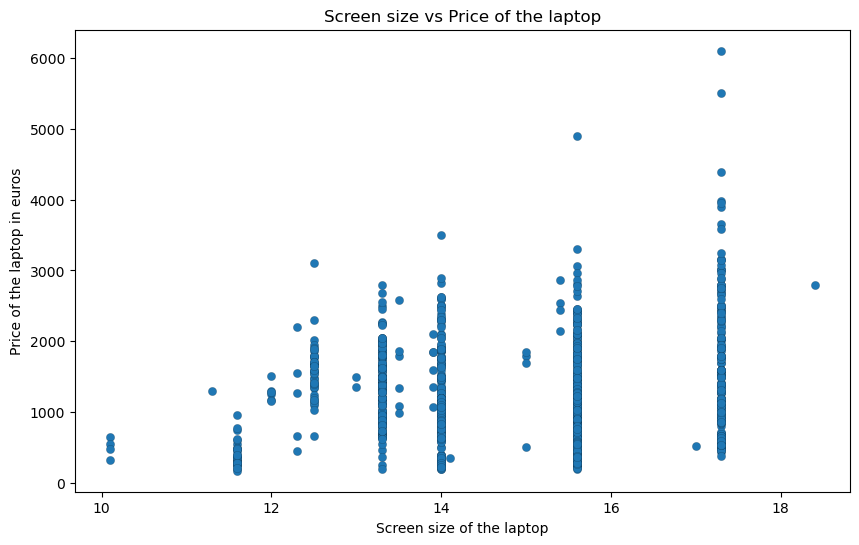

In [13]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Screen_Size", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Screen size of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("Screen size vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- We can see that there is a **no specific relationship** between **Screen size and price** of a laptop, because though with the **increase in size price is also increasing** but still there are many laptops **available in the same price with bigger screen size**. 

#### 2. **`Ram`** vs **`Price_euros`**

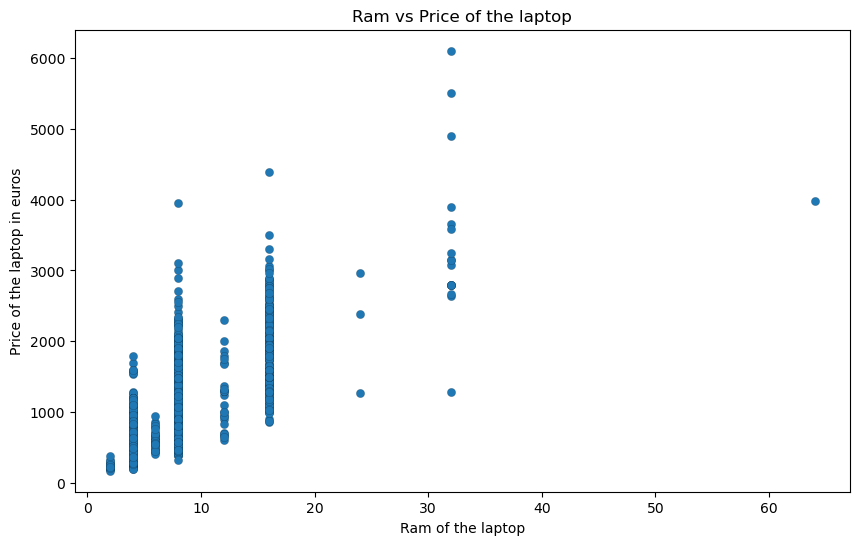

In [14]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Ram", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Ram of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("Ram vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- Here we can see that there is not very strong but **a positive relationship** is there between **ram** and **price** as the ram is increasing the **price** of the laptop is also increasing.

#### 3. **`Weight`** vs **`Price_euros`**

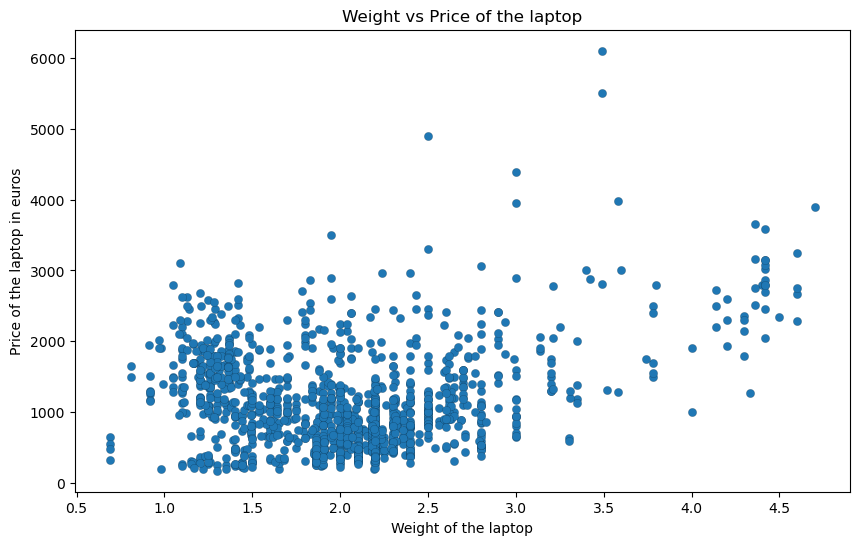

In [15]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Weight", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Weight of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("Weight vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- Here we can see that there is not a very strong but **a positive relationship** is there between **weight** and **price** as the weight is increasing the price of the laptop is also increasing but then **there are many are many cases where weight is not affecting the price**.

#### 4. **`Screen_Width`** vs **`Price_euros`**

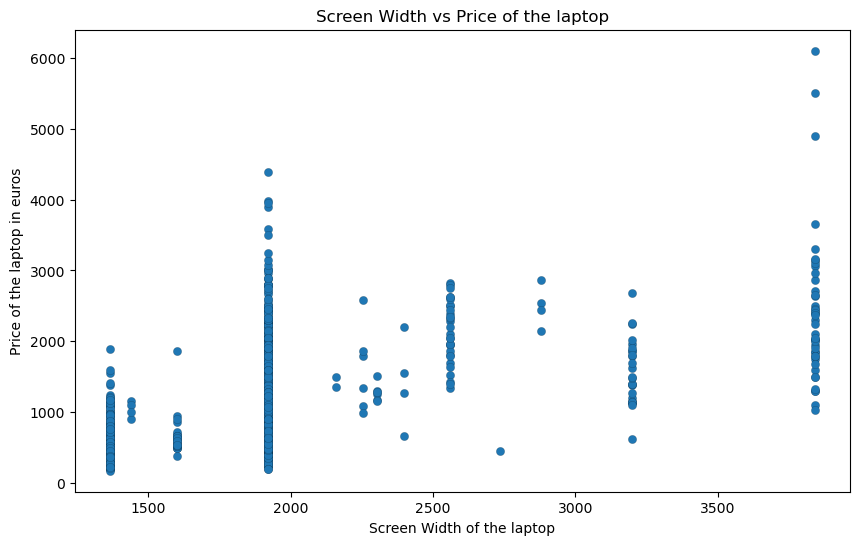

In [16]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Screen_Width", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Screen Width of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("Screen Width vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- Again we can see that there is no much relation between the screen **width** and **price**.

#### 5. **`Screen_Height`** vs **`Price_euros`**

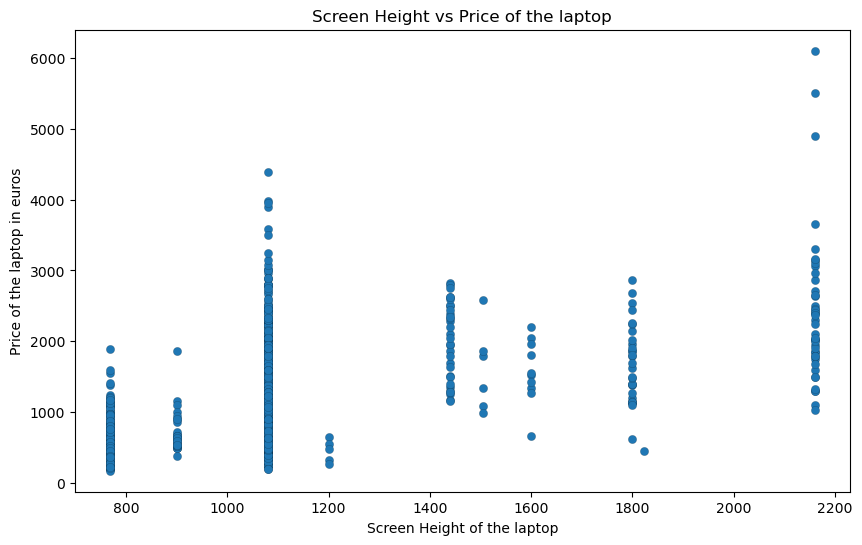

In [17]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Screen_Height", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Screen Height of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("Screen Height vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- Same as **Width's** relation with **Price** no much relation with **Height** also.

#### 6. **`CPU_frequency`** vs **`Price_euros`**

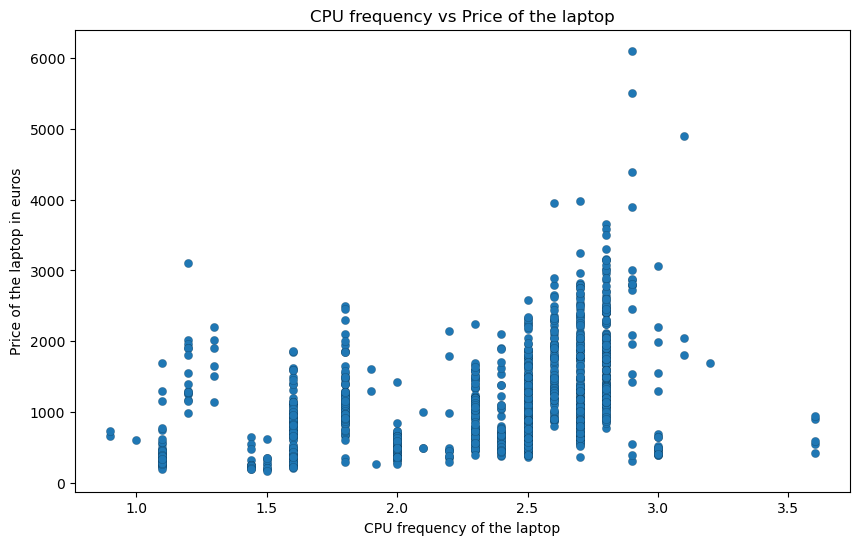

In [18]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "CPU_frequency", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("CPU frequency of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("CPU frequency vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- We can again see that there are not much **strong relationship** between **CPU frequency** and **Price** of the laptop.

#### 7. **`Primary_Storage`** vs **`Price_euros`**

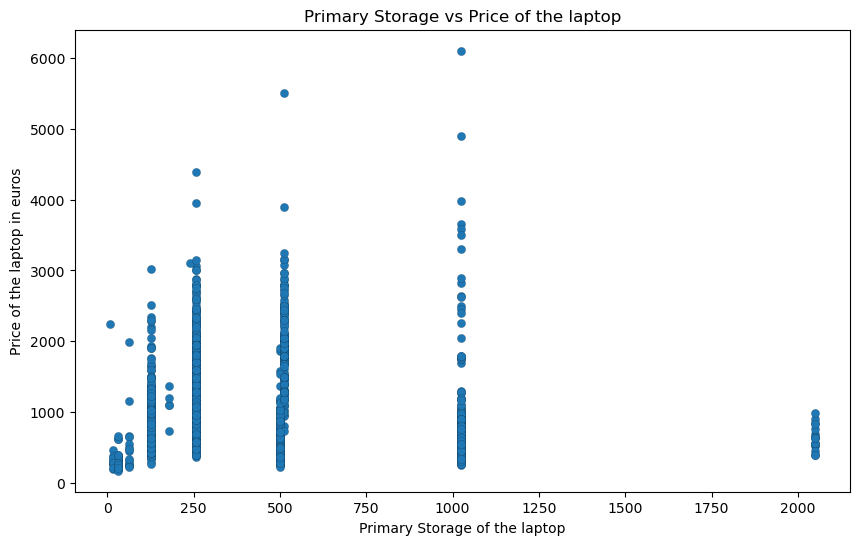

In [19]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Primary_Storage", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Primary Storage of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("Primary Storage vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- Here again we can see that there laptops available of **same primary storage sizes in different prices** meaning again there is not much **strong relationship** here and there can be certain outliers also present.

#### 8. **`Secondary_Storage`** vs **`Price_euros`**

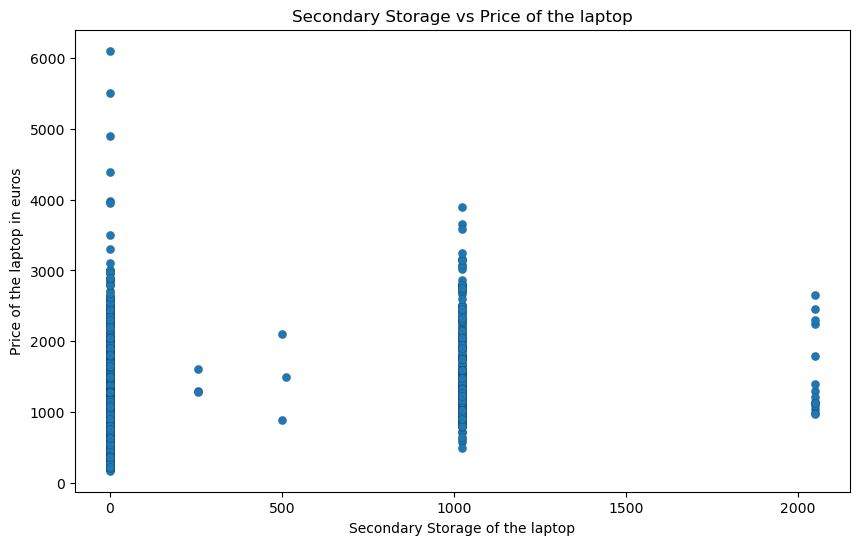

In [20]:
# Setting the figure for the graph
plt.figure(figsize = [10,6])

# Plotting the graph
sns.scatterplot(x = "Secondary_Storage", y = "Price_euros", data = df_laptop_price_data, edgecolor = "black", linewidth = 0.1)

# Setting the name of x axis
ax = plt.gca()
ax.set_xlabel("Secondary Storage of the laptop")

# Setting the name of y axis
ax.set_ylabel("Price of the laptop in euros")

# Setting the title
ax.set_title("Secondary Storage vs Price of the laptop")

# Displaying the graph
plt.show()

**Interpretation**

- Here again we can see **secondary storage** also **does not have any strong relation** with the **price** of the laptop.

### 2. Numerical-Categorical column pair.

Here we are going to plot1 graphs for pairs of columns, we'll make the pairs with target column **`Price_euros`**.

#### a. Bar chart for **`Company`** and **`Price_euros`** columns.

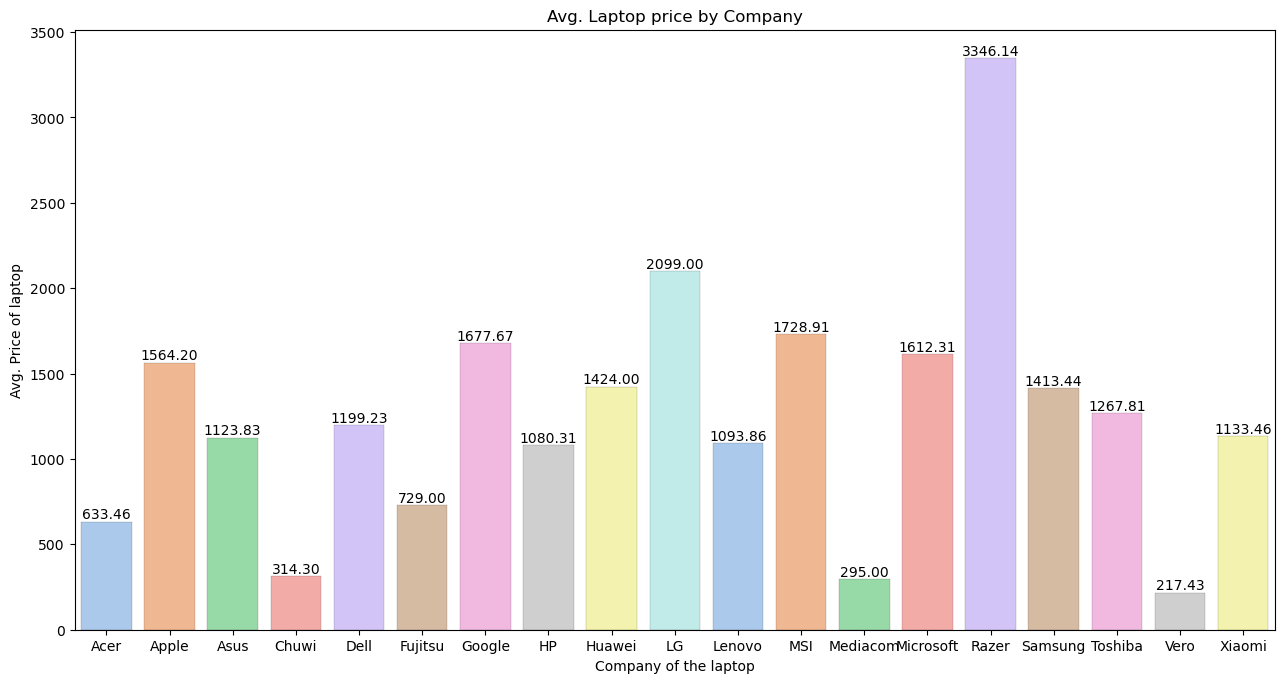

In [21]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_Company = df_laptop_price_data.groupby('Company')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Company', y = 'Price_euros', data = avg_price_by_Company, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Company of the laptop")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by Company")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- Here we can see that for most of the Companies the price range is between **1080.31** to **1728.91** Euros.
- Then there are certain companies with different prices then the rest such as **Razor** company with highest avg. price of laptop.
- And **Vero** has the lowest laptop price.

#### b. Bar chart for **`Type_Name`** and **`Price_euros`** columns.

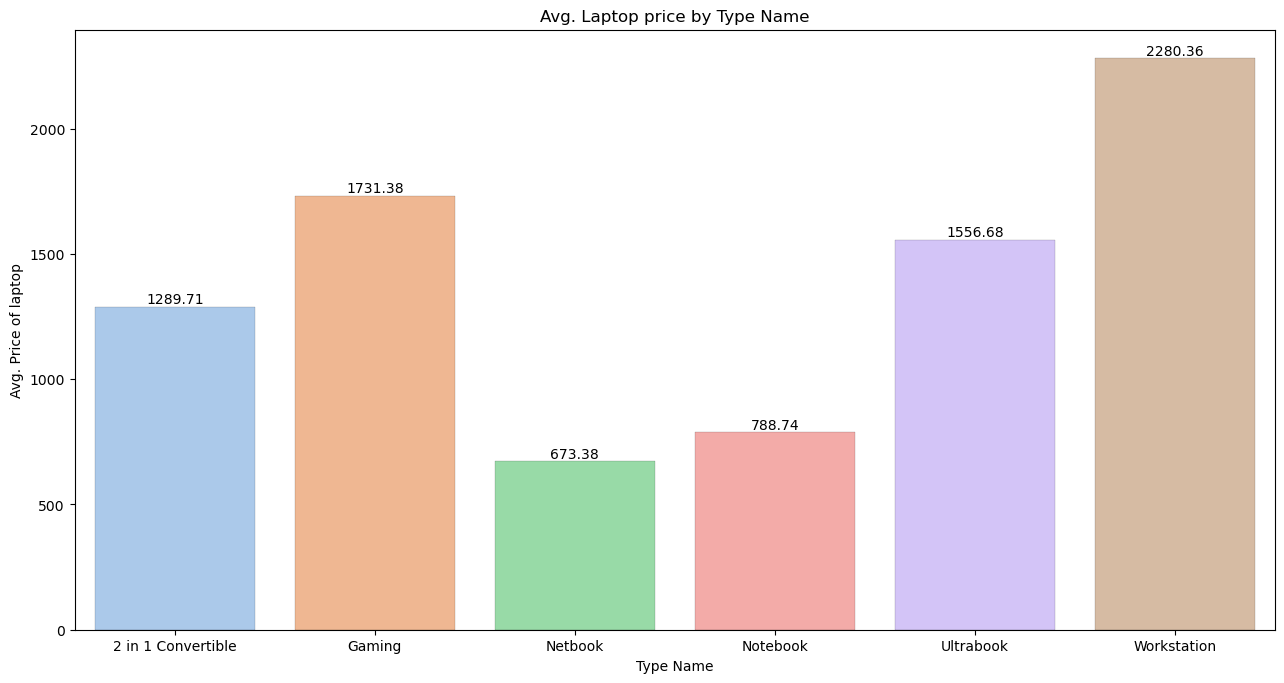

In [22]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_Type_Name = df_laptop_price_data.groupby('Type_Name')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', data = avg_price_by_Type_Name, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Type Name")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by Type Name")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- Here we can see that the **Workstation** laptop type has highest average price i.e. **2280.36** Euros.
- And the **Netbook** laptop type has the lowest average price i.e. **673.38** Euros and Second lowest is **Notebook** type i.e. **788.74** Euros price.
- Rest of the laptop types have a price range from **1289.71** to **1731.38**. 

#### c. Bar chart for **`OS`** and **`Price_euros`** columns.

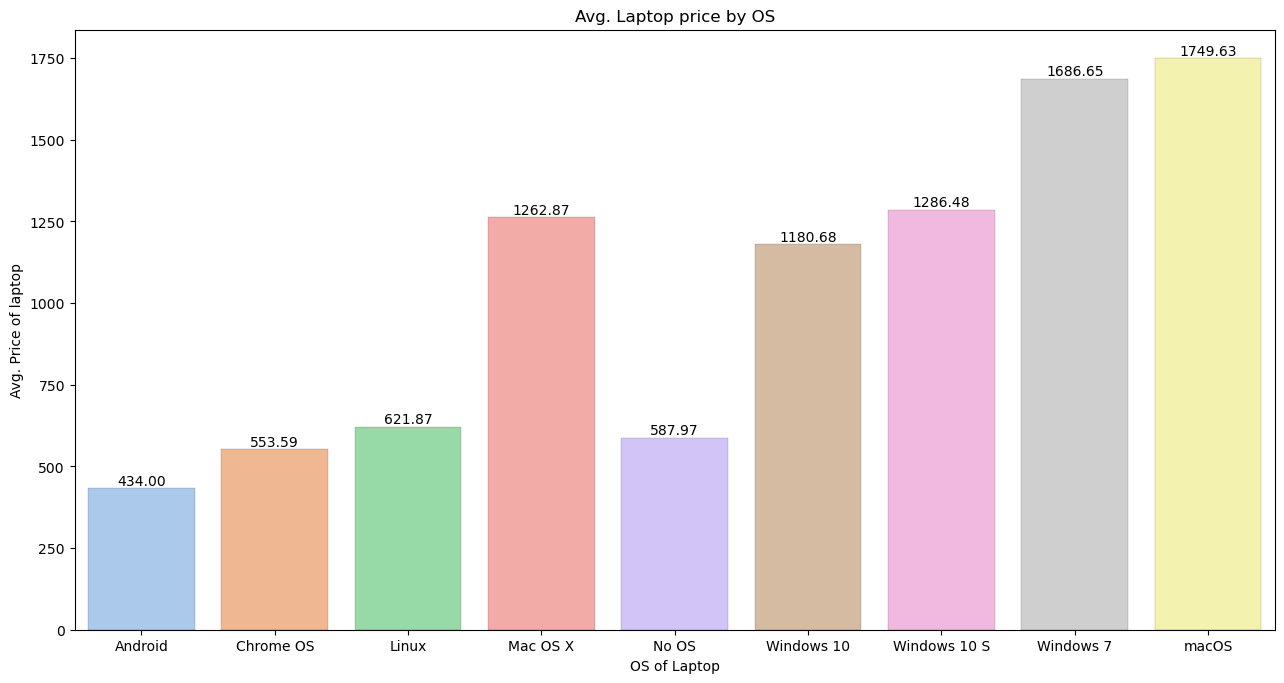

In [23]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_OS = df_laptop_price_data.groupby('OS')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'OS', y = 'Price_euros', data = avg_price_by_OS, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("OS of Laptop")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by OS")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- Here we can see that the laptops with **macOS** highest average price i.e. **1749.63** Euros.
- Rest of the laptop types have a price range from **434.00** to **621.87** and another range is from **1180.68** to **1686.65**. 

#### d. Bar chart for **`Screen_Definition`** and **`Price_euros`** columns.

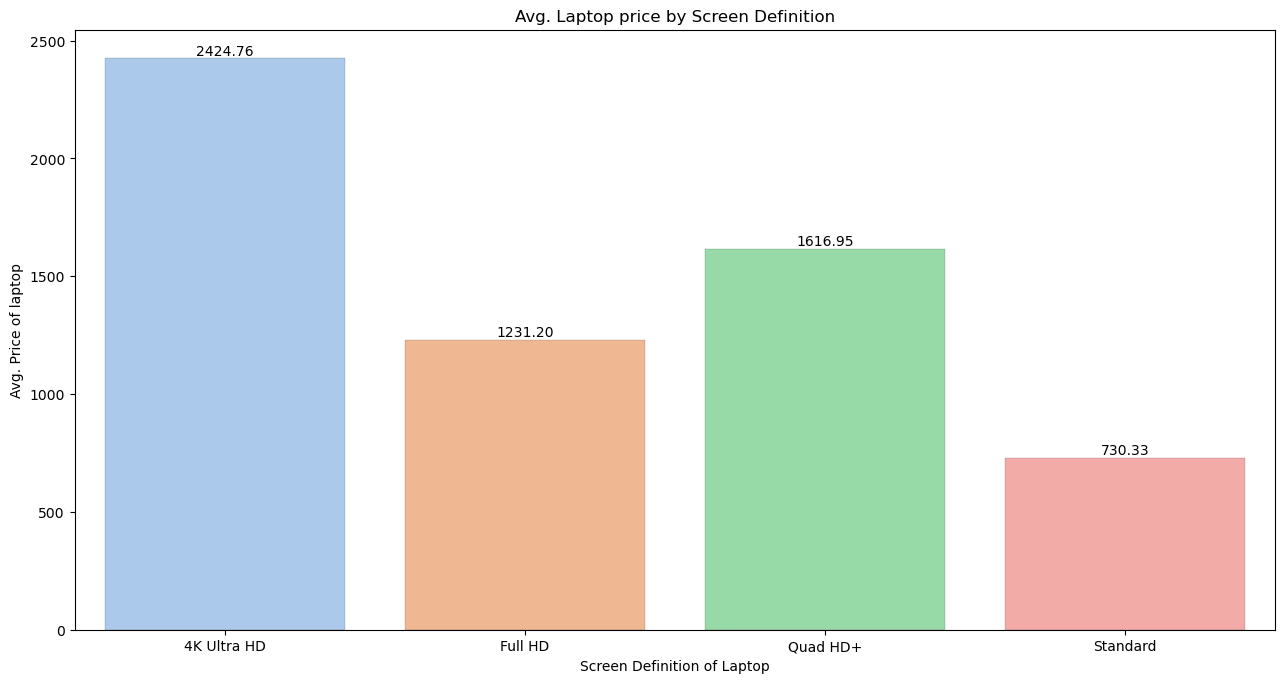

In [24]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_Screen_Definition = df_laptop_price_data.groupby('Screen_Definition')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Screen_Definition', y = 'Price_euros', data = avg_price_by_Screen_Definition, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Screen Definition of Laptop")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by Screen Definition")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- As we can see here that the highest average price of laptops is of laptops with **4k Ultra HD** Screen Definition i.e. **2424.76** Euros.
- For rest of the screens the average price ranges from **730.33** to **1616.95** Euros. This tells us that Screen Definition has a huge impact on Laptop prices.

#### e. Bar chart for **`Touchscreen`** and **`Price_euros`** columns.

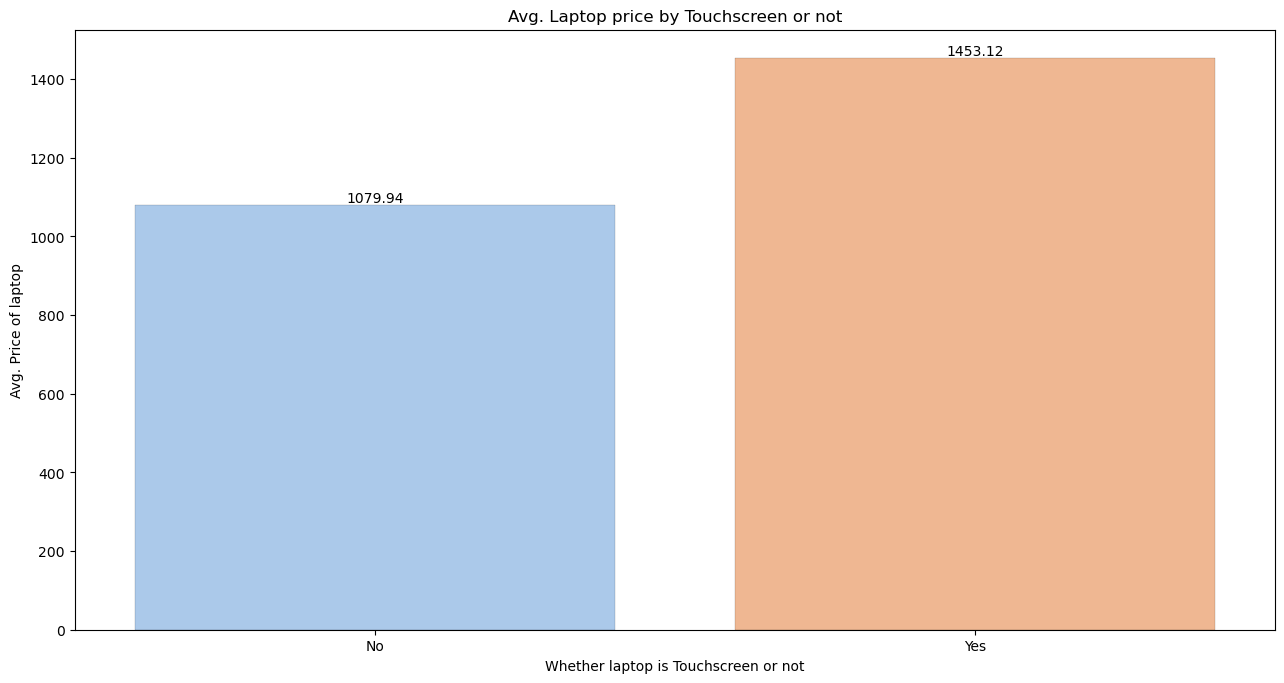

In [25]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_Touchscreen = df_laptop_price_data.groupby('Touchscreen')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Touchscreen', y = 'Price_euros', data = avg_price_by_Touchscreen, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Whether laptop is Touchscreen or not")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by Touchscreen or not")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- As we can see the clear difference here that for laptops with **Touchscreen** feature the average price is higher than for non touchscreen laptops.

#### f. Bar chart for **`IPS_panel`** and **`Price_euros`** columns.

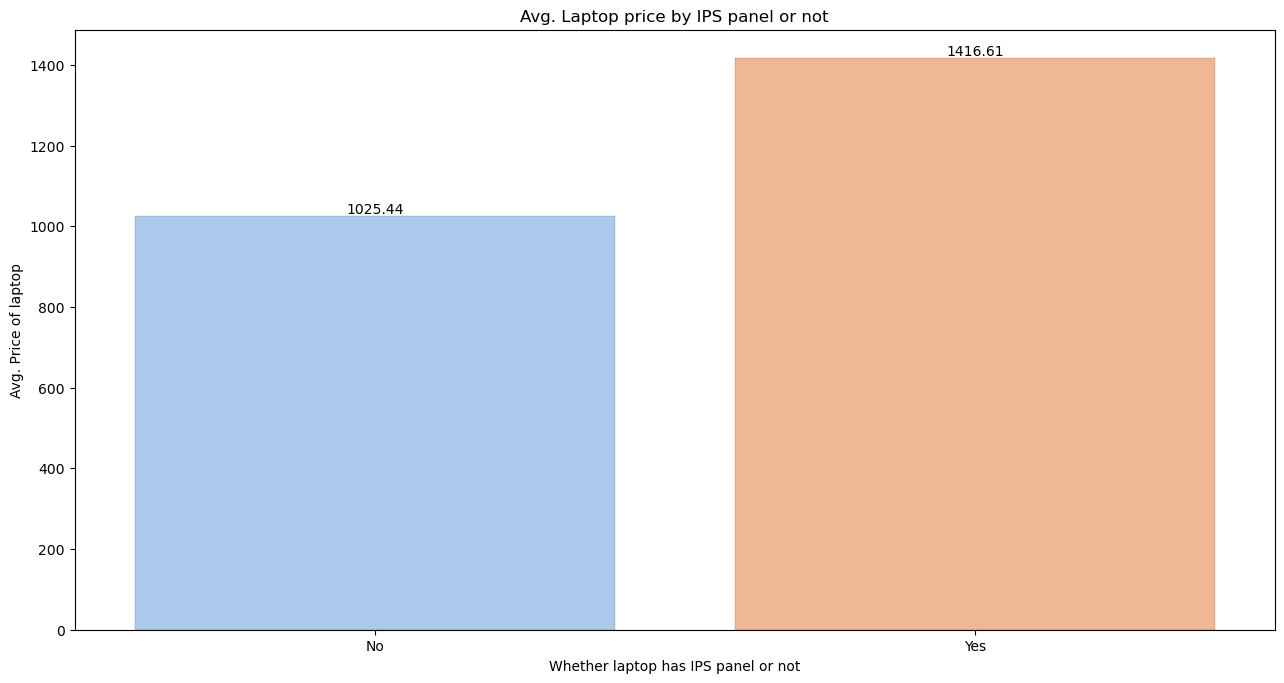

In [26]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_IPS_panel = df_laptop_price_data.groupby('IPS_panel')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'IPS_panel', y = 'Price_euros', data = avg_price_by_IPS_panel, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Whether laptop has IPS panel or not")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by IPS panel or not")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- Here also we can see the clear difference here that for laptops with **IPS panel** has the average price higher than the laptops which does not have IPS panel.

#### g. Bar chart for **`Retina_Display`** and **`Price_euros`** columns.

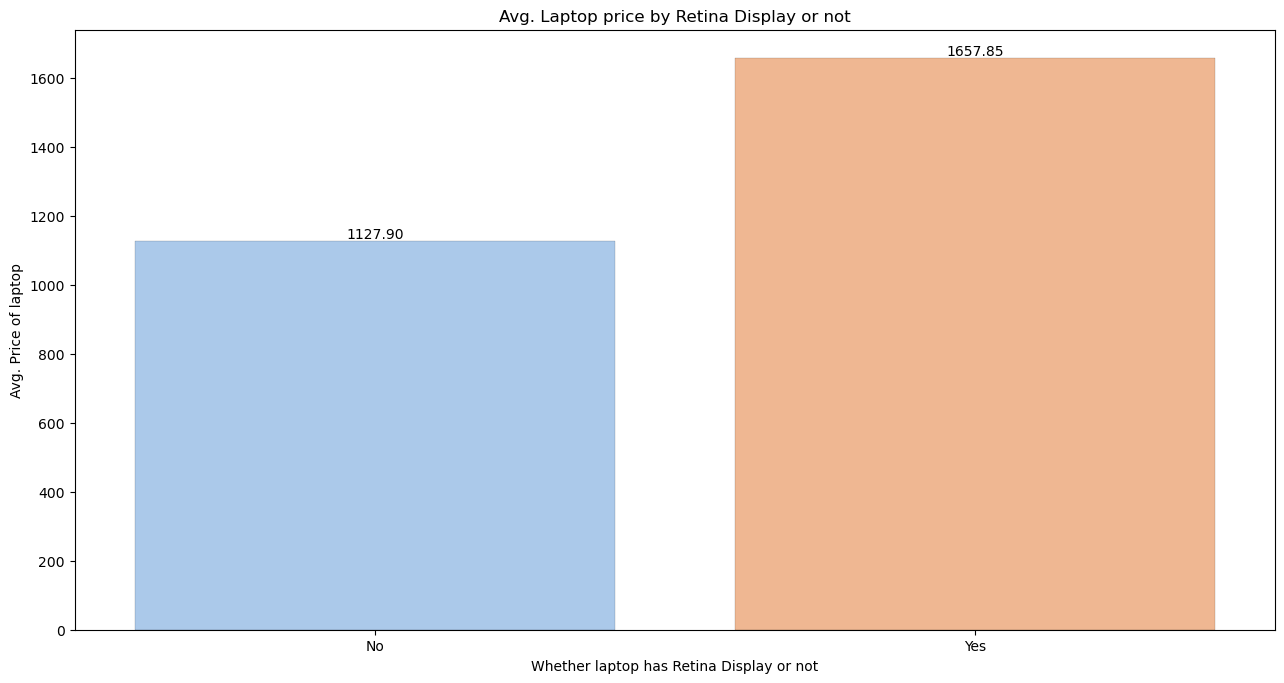

In [27]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_Retina_Display = df_laptop_price_data.groupby('Retina_Display')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Retina_Display', y = 'Price_euros', data = avg_price_by_Retina_Display, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Whether laptop has Retina Display or not")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by Retina Display or not")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- Here also we can see the clear difference here that for laptops having **Retina Display** has the average price higher than the laptops which does not have Retina Display.

#### h. Bar chart for **`CPU_company`** and **`Price_euros`** columns.

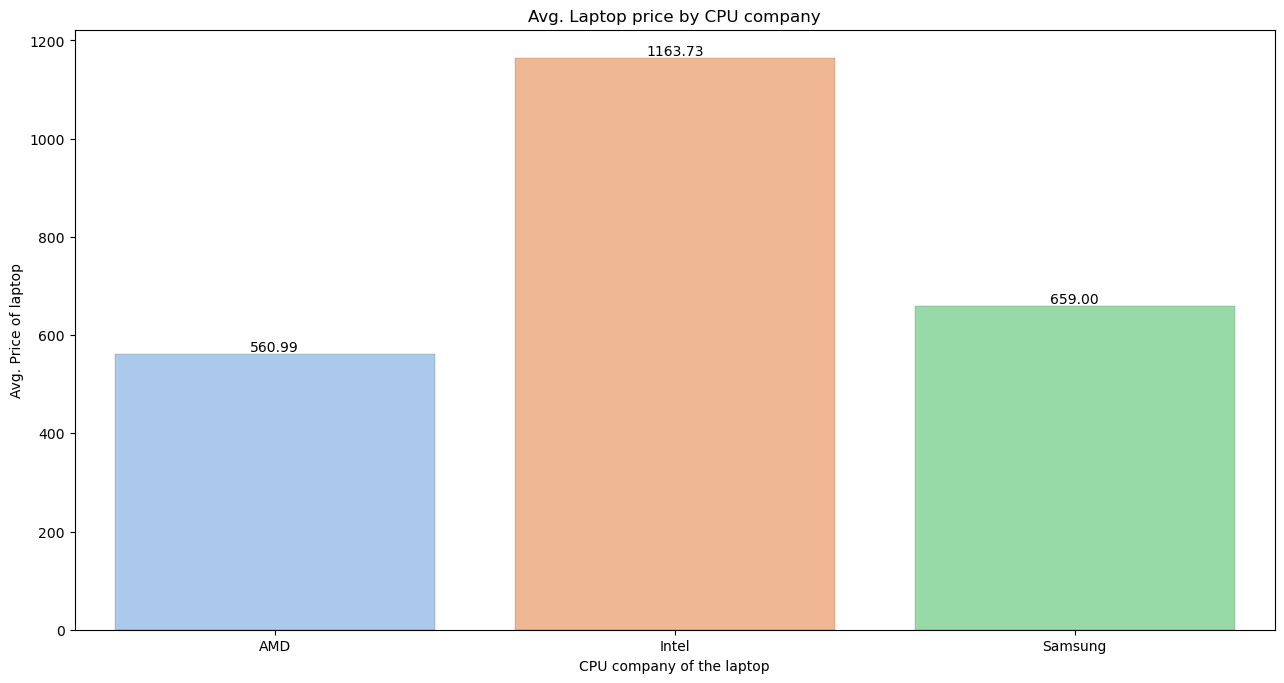

In [28]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_CPU_company = df_laptop_price_data.groupby('CPU_company')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'CPU_company', y = 'Price_euros', data = avg_price_by_CPU_company, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("CPU company of the laptop")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by CPU company")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- We can see that one company is dominating the averages prices of laptop i.e. **Intel** as the laptops with Intel CPUs have the highest average prices.
- On the otherhand **AMD** and **Samsung** have similar prices which ranges from **560.99** to **659.00** Euros. 

#### i. Bar chart for **`Primary_Storage_Type`** and **`Price_euros`** columns.

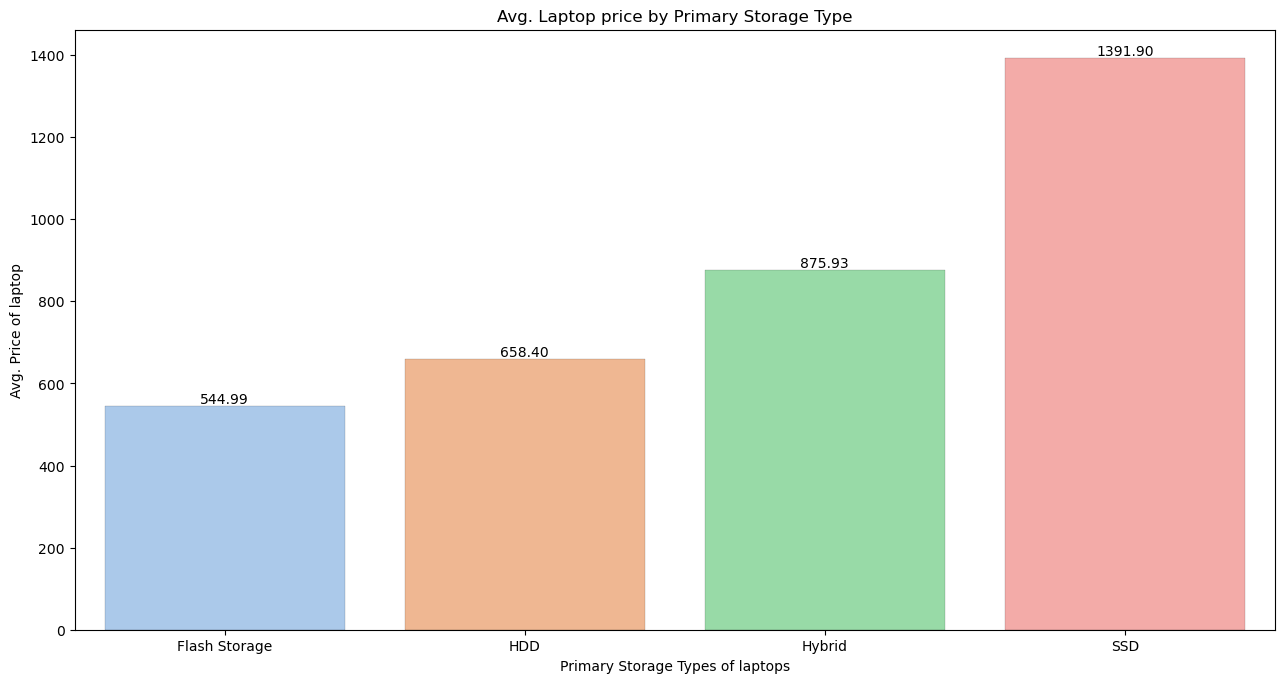

In [29]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_Primary_Storage_Type = df_laptop_price_data.groupby('Primary_Storage_Type')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Primary_Storage_Type', y = 'Price_euros', data = avg_price_by_Primary_Storage_Type, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Primary Storage Types of laptops")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by Primary Storage Type")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- We can see that one type of primary storage is dominating the averages prices of laptops i.e. **SSD** as the laptops with SSD as primary storage types have the highest average prices.
- On the otherhand **Flash Storage**, **HDD** and **Hybrid** have similar prices which ranges from **544.99** to **875.93** Euros.

#### j. Bar chart for **`Secondary_Storage_Type`** and **`Price_euros`** columns.

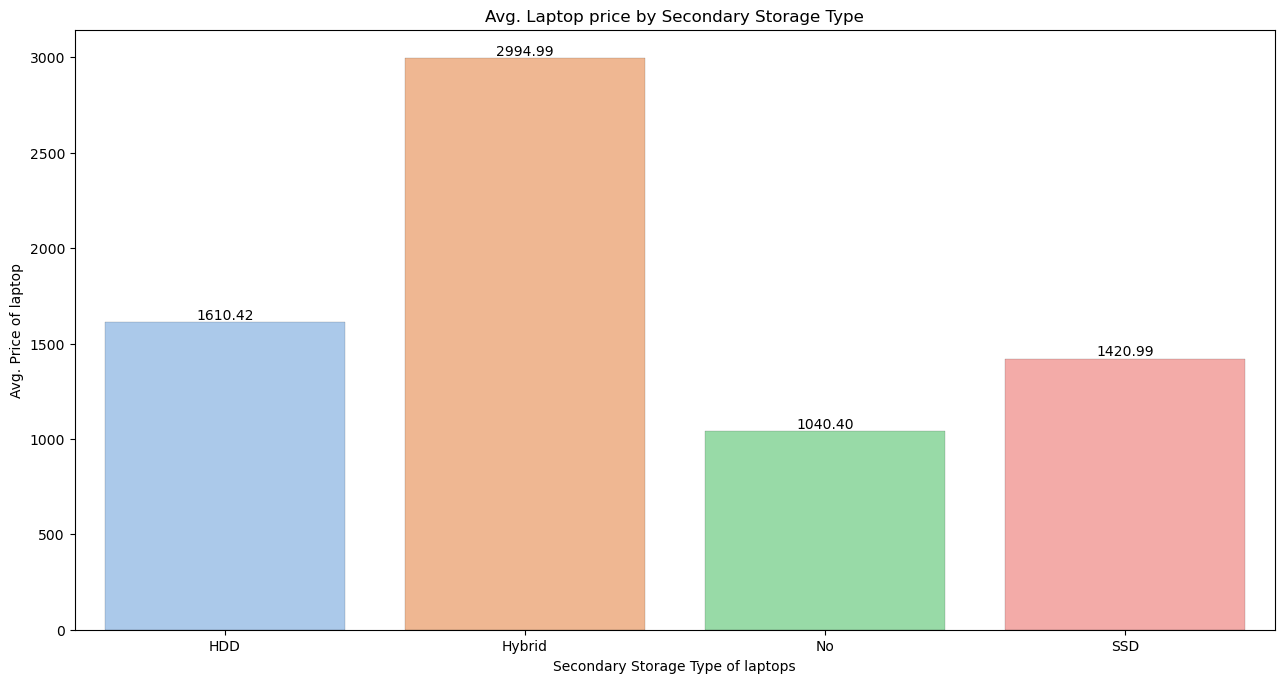

In [30]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_Secondary_Storage_Type = df_laptop_price_data.groupby('Secondary_Storage_Type')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Secondary_Storage_Type', y = 'Price_euros', data = avg_price_by_Secondary_Storage_Type, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("Secondary Storage Type of laptops")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by Secondary Storage Type")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- We can see here that Secondary Storages of **Hybrid** type has the highest avg. prices of laptop.
- While **HDD** and **SSD** or **No** Secondary Storage leads to laptop prices ranging between **1040.40** to **1610.42** Euros.

#### j. Bar chart for **`GPU_company`** and **`Price_euros`** columns.

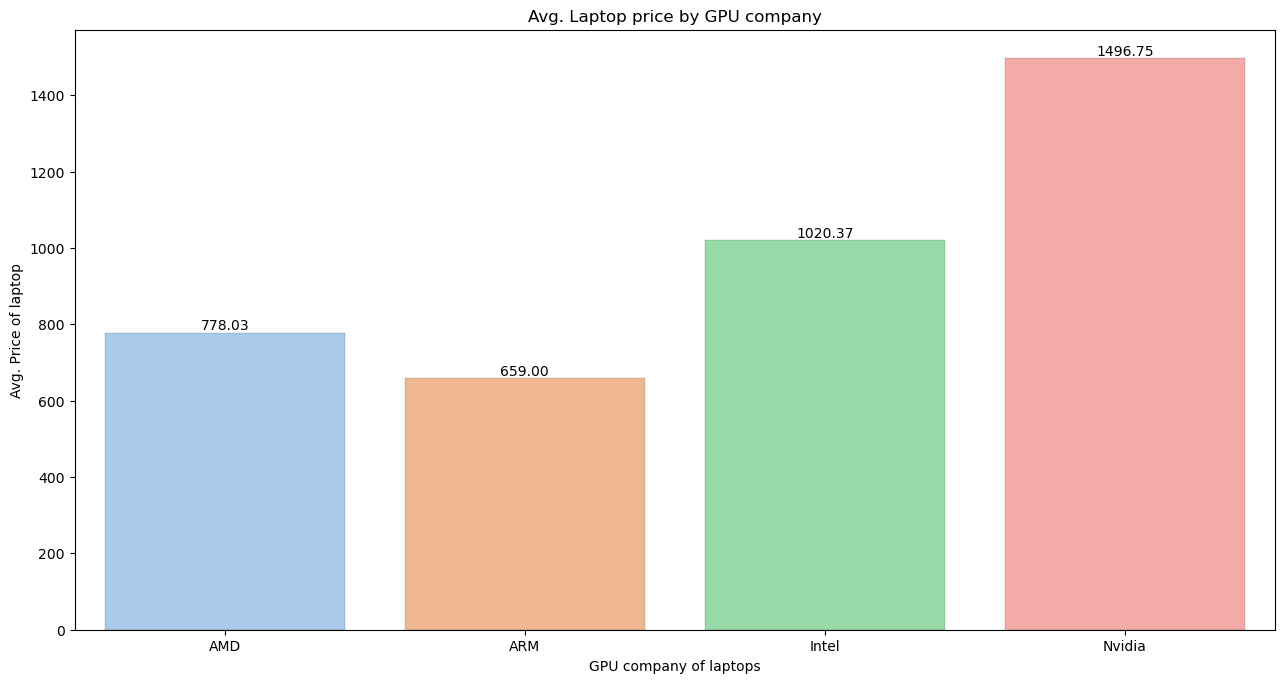

In [31]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_price_by_GPU_company = df_laptop_price_data.groupby('GPU_company')['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'GPU_company', y = 'Price_euros', data = avg_price_by_GPU_company, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting name of x axis
ax.set_xlabel("GPU company of laptops")

# Setting name of y axis
ax.set_ylabel("Avg. Price of laptop")

# Setting the title for the graph
ax.set_title("Avg. Laptop price by GPU company")

# Setting bar values
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f')

# Displaying the graph
plt.show()

**Interpretation**

- We can see here that laptops having GPUs of **Nvidia** has the highest average price i.e. **1496.75** Euros.
- Second highest is **Intel** GPU based laptops with average price i.e. **1020.37**.
- While **AMD** and **ARM** GPU based laptops has average price ranging between **659.00** to **778.03**. 

## c) Multivariate Analysis

Here we are going to plot graphs for each of the column groups such as **Categorical-Categorical-Numerical** group, **Numerical-Numerical-Categorical** group.

### 1. Categorical-Categorical-Numerical column group.

Here we will choose combinations of categorical columns against **Price** column.

#### a. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`OS`**

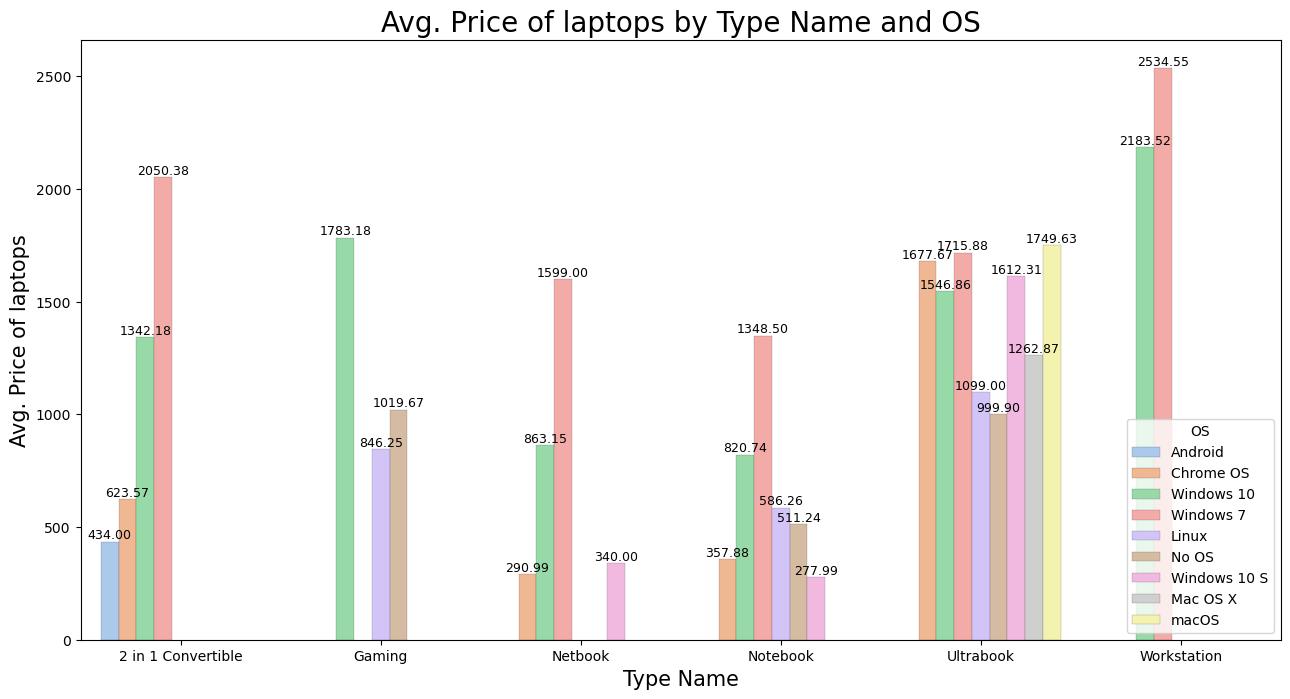

In [32]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_OS_and_Type_Name = df_laptop_price_data.groupby(['Type_Name', 'OS'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'OS', data = avg_Price_by_OS_and_Type_Name, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "OS", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and OS", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) and operating systems (OS).

---

### 1. Overall Price Trends
- Workstations are the most expensive laptops across almost all operating systems.
- Netbooks and Notebooks are generally the most affordable categories.
- Ultrabooks fall in the mid-to-high price range due to their premium design and portability.

---

### 2. OS-Based Price Insights
- Windows 7 laptops tend to have the highest average prices in most categories (e.g., Workstations ~2534, 2-in-1 ~2050).
- Windows 10 laptops show consistently high prices but slightly lower than Windows 7.
- Linux and No OS laptops are generally cheaper, indicating budget or developer-focused devices.
- MacOS laptops (Ultrabooks and Workstations) are among the most expensive, reflecting premium Apple hardware.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- Prices range widely.
- Windows 7 (2050) is significantly more expensive than others.
- Android (434) is the cheapest.

#### Gaming Laptops
- High prices overall.
- Windows 10 (1783) dominates.
- Linux and No OS versions are moderately priced.

#### Netbooks
- Lowest price category.
- Mostly limited OS options.
- Prices stay below ~1600.

#### Notebooks
- Affordable and widely used.
- Prices range from 277 to 1348.
- Windows 7 again is the most expensive.

#### Ultrabooks
- Premium segment.
- Prices are consistently high across all OS.
- macOS (1749) and Windows 7 (1715) are among the top.

#### Workstations
- Most expensive category.
- Windows 7 (2534) and Windows 10 (2183) dominate.
- Designed for professional/high-performance tasks.

---

### 4. Key Takeaways
- Laptop type has a strong influence on price, with Workstations being the most expensive.
- Operating system also impacts pricing, with older enterprise OS (Windows 7) showing unexpectedly high averages.
- MacOS devices are consistently premium-priced, especially in Ultrabooks and Workstations.
- Budget options are mostly found in Linux, No OS, and Android-based laptops.

---

### Final Insight
The graph highlights that both hardware category (type) and software ecosystem (OS) play crucial roles in determining laptop pricing, with premium performance categories and proprietary ecosystems commanding higher prices.

#### b. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`Screen_Definition`**

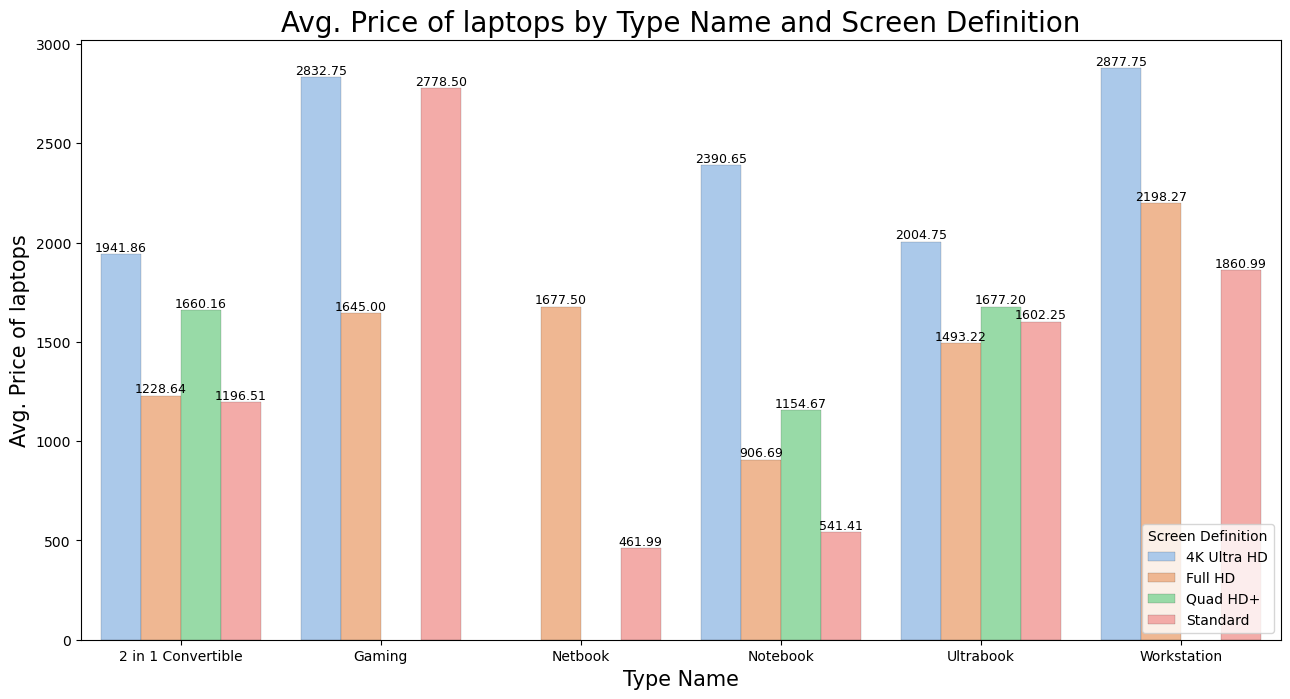

In [33]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_Screen_Definition = df_laptop_price_data.groupby(['Type_Name', 'Screen_Definition'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'Screen_Definition', data = avg_Price_by_Type_Name_and_Screen_Definition, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "Screen Definition", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and Screen Definition", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on screen definitions (4K Ultra HD, Full HD, Quad HD+, Standard).

---

### 1. Overall Price Trends
- Laptops with higher screen resolutions (especially 4K Ultra HD) are consistently more expensive.
- Standard resolution laptops are generally the cheapest across all categories.
- Workstations and Gaming laptops remain the most expensive categories regardless of screen type.

---

### 2. Screen Definition-Based Price Insights
- 4K Ultra HD laptops have the highest average prices in almost all categories, reflecting premium display technology.
- Full HD laptops fall in the mid-range and are widely available across all categories.
- Quad HD+ laptops are priced between Full HD and 4K, offering a balance between cost and quality.
- Standard displays are the most budget-friendly, especially in categories like Netbooks and Notebooks.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- Prices range from 1196 (Standard) to 1941 (4K).
- Clear increase in price with higher resolution.

#### Gaming Laptops
- Among the most expensive categories.
- 4K (2832) and Standard (2778) are both very high, indicating premium configurations.
- Full HD (1645) is comparatively lower but still expensive.

#### Netbooks
- Lowest-priced category overall.
- Limited screen options available.
- Full HD (1677) is higher than Standard (461), showing a large price gap.

#### Notebooks
- Moderate pricing category.
- 4K (2390) significantly higher than other resolutions.
- Standard (541) remains the cheapest.

#### Ultrabooks
- Premium segment with consistent pricing.
- 4K (2004) is highest, followed by Quad HD+ (1677) and Standard (1602).
- Less variation compared to other categories.

#### Workstations
- Most expensive overall.
- 4K (2877) is the highest in the entire graph.
- Prices remain high across all resolutions, including Full HD (~2198) and Standard (~1860).

---

### 4. Key Takeaways
- Screen resolution has a strong impact on laptop pricing, with higher resolutions leading to higher costs.
- 4K Ultra HD is a major premium factor across all laptop types.
- Workstations and Gaming laptops consistently dominate the high-price segment.
- Budget-friendly options are mostly found in Standard and some Full HD configurations, especially in Netbooks and Notebooks.

---

### Final Insight
The graph demonstrates that both laptop type and screen definition significantly influence pricing. Higher resolution displays, particularly 4K Ultra HD, substantially increase the cost, especially in high-performance categories like Workstations and Gaming laptops.

#### c. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`Touchscreen`**

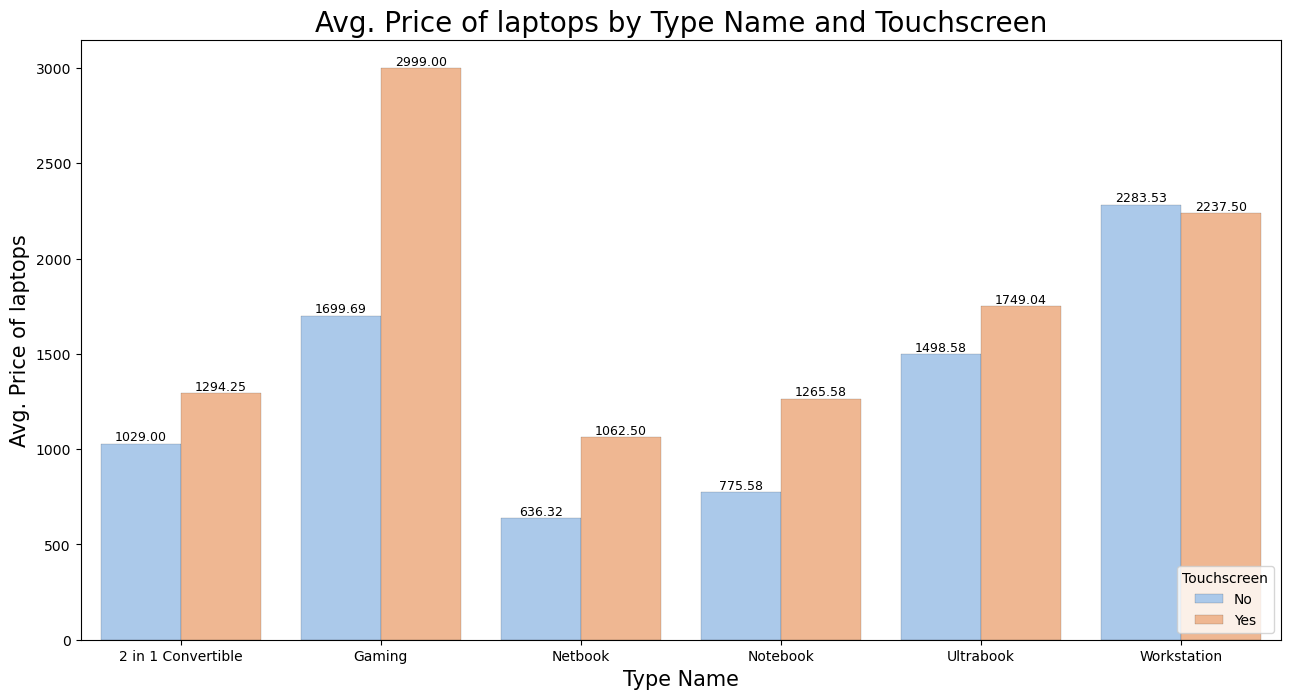

In [34]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_Touchscreen = df_laptop_price_data.groupby(['Type_Name', 'Touchscreen'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'Touchscreen', data = avg_Price_by_Type_Name_and_Touchscreen, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "Touchscreen", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and Touchscreen", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on whether they have a touchscreen or not.

---

### 1. Overall Price Trends
- Laptops with touchscreen functionality are generally more expensive than non-touchscreen laptops.
- The price difference varies depending on the laptop category.
- Workstations and Gaming laptops remain the most expensive categories overall.

---

### 2. Touchscreen vs Non-Touchscreen Insights
- Touchscreen laptops consistently show higher average prices across most categories.
- The added cost reflects additional hardware, display technology, and enhanced user interaction features.
- Non-touchscreen laptops are more budget-friendly and common in entry-level and standard-use categories.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- Touchscreen laptops (1294.25) are more expensive than non-touchscreen ones (1029.00).
- This is expected as 2-in-1 devices often rely on touch functionality.

#### Gaming Laptops
- A significant price difference is observed.
- Touchscreen models (2999.00) are much more expensive than non-touchscreen models (1699.69).
- Indicates premium gaming configurations with added features.

#### Netbooks
- Lower-priced category overall.
- Touchscreen laptops (1062.50) are notably more expensive than non-touchscreen ones (636.32).

#### Notebooks
- Moderate pricing category.
- Touchscreen laptops (1265.58) cost more than non-touchscreen models (775.58).

#### Ultrabooks
- Premium segment.
- Touchscreen models (1749.04) are more expensive than non-touchscreen ones (1498.58), but the difference is smaller compared to Gaming laptops.

#### Workstations
- Most expensive category overall.
- Non-touchscreen laptops (2283.53) are slightly more expensive than touchscreen models (2237.50).
- This suggests that performance hardware matters more than touchscreen capability in this category.

---

### 4. Key Takeaways
- Touchscreen functionality generally increases laptop prices across most categories.
- The impact of touchscreen on price is most significant in Gaming and Netbook categories.
- In high-performance categories like Workstations, touchscreen has minimal influence on pricing.
- Budget-conscious users can opt for non-touchscreen models, especially in Notebooks and Netbooks.

---

### Final Insight
The graph shows that touchscreen capability is a value-adding feature that increases laptop prices in most cases. However, its impact varies by category, with the strongest influence seen in consumer-focused laptops and less importance in performance-driven devices like Workstations.

#### d. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`IPS_panel`**

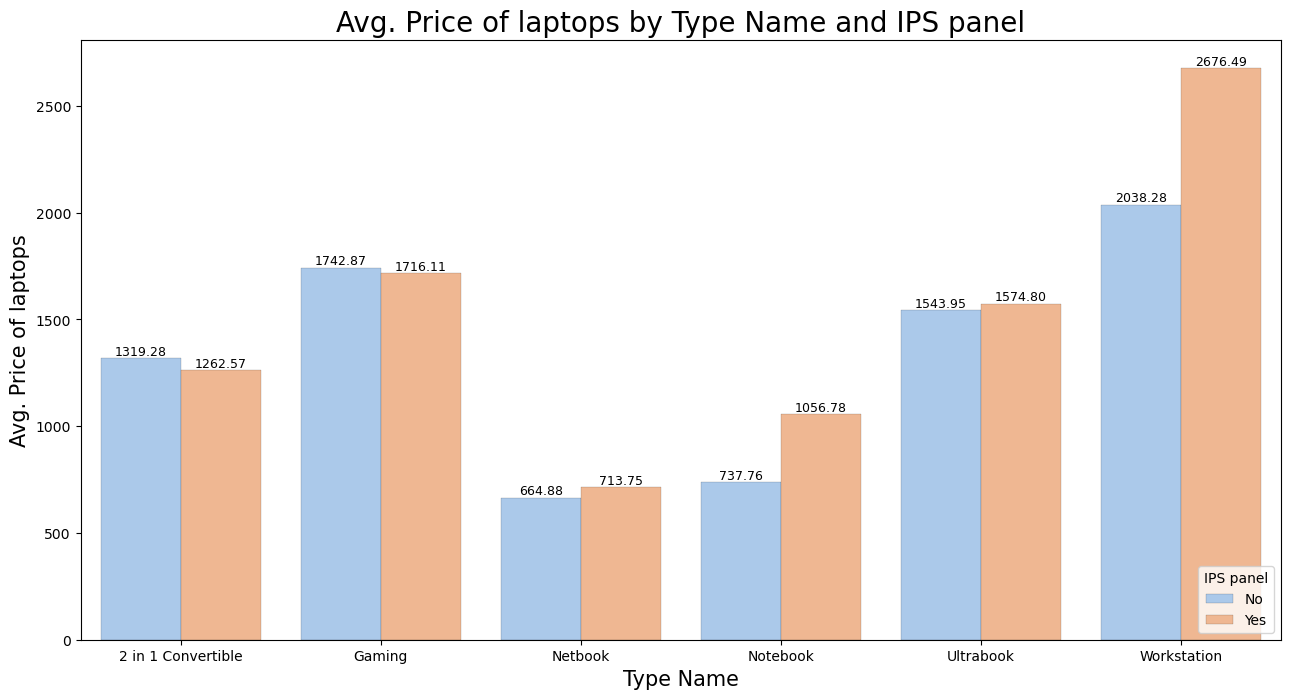

In [35]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_IPS_panel = df_laptop_price_data.groupby(['Type_Name', 'IPS_panel'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'IPS_panel', data = avg_Price_by_Type_Name_and_IPS_panel, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "IPS panel", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and IPS panel", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on whether they have an IPS panel or not.

---

### 1. Overall Price Trends
- Laptops with IPS panels are generally more expensive than those without.
- The price difference varies depending on the laptop category.
- Workstations and Gaming laptops remain the most expensive categories overall.

---

### 2. IPS Panel vs Non-IPS Insights
- IPS panel laptops tend to have higher average prices due to better display quality, color accuracy, and viewing angles.
- Non-IPS laptops are usually more affordable and common in budget or basic-use devices.
- The price impact of IPS panels is more noticeable in certain categories like Notebooks and Workstations.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- Non-IPS laptops (1319.28) are slightly more expensive than IPS models (1262.57).
- This is an exception where IPS does not increase price.

#### Gaming Laptops
- Prices are very close.
- Non-IPS (1742.87) is slightly higher than IPS (1716.11), showing minimal impact of IPS panels.

#### Netbooks
- IPS laptops (713.75) are slightly more expensive than non-IPS ones (664.88).
- The difference is small due to the budget nature of this category.

#### Notebooks
- Clear price increase with IPS panels.
- IPS (1056.78) is significantly higher than non-IPS (737.76).

#### Ultrabooks
- IPS laptops (1574.80) are slightly more expensive than non-IPS (1543.95).
- The difference is small, suggesting IPS is almost standard in this segment.

#### Workstations
- Significant price difference.
- IPS laptops (2676.49) are much more expensive than non-IPS (2038.28).
- Indicates high-end professional use where display quality is critical.

---

### 4. Key Takeaways
- IPS panels generally increase laptop prices, especially in mid-range and high-end categories.
- The impact of IPS is minimal in Gaming and 2-in-1 categories.
- Workstations show the strongest price difference, highlighting the importance of display quality in professional tasks.
- In premium segments like Ultrabooks, IPS panels are almost standard, leading to smaller price gaps.

---

### Final Insight
The graph shows that IPS panel technology adds value and increases laptop prices in most cases. However, its influence varies by category, with the strongest impact in professional and productivity-focused laptops, while being less significant in performance-oriented or hybrid devices.

#### e. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`Retina_Display`**

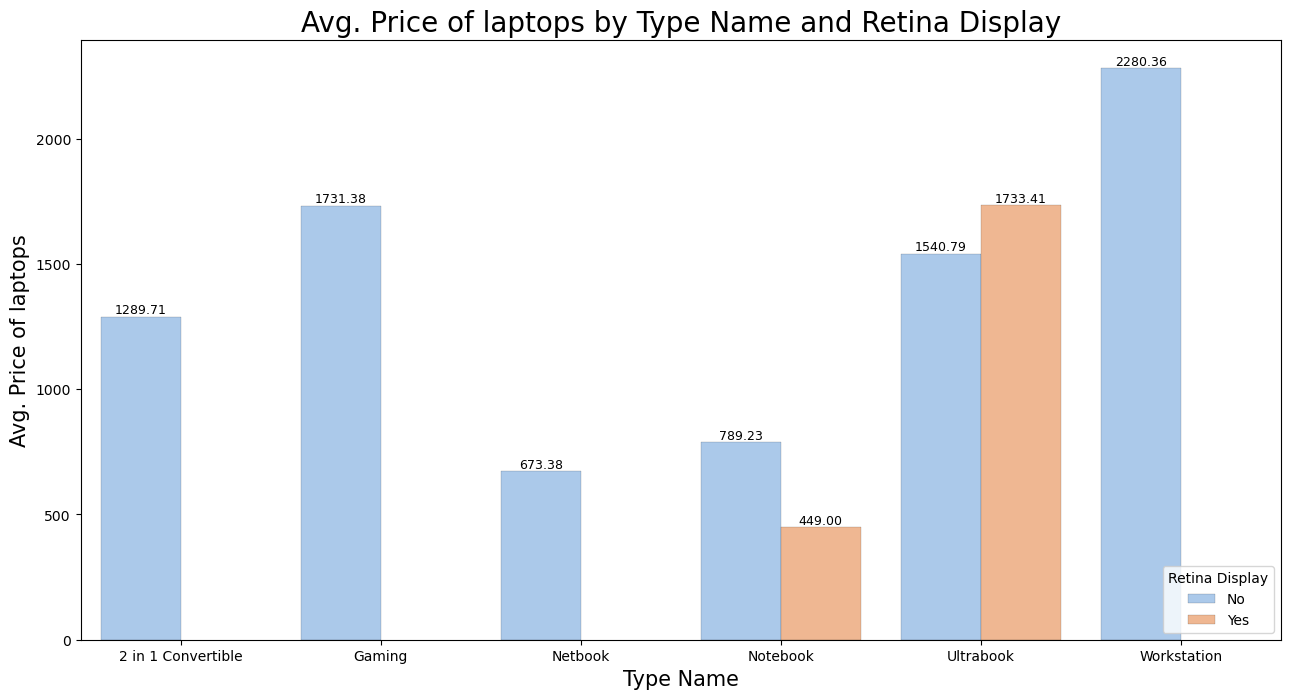

In [36]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_Retina_Display = df_laptop_price_data.groupby(['Type_Name', 'Retina_Display'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'Retina_Display', data = avg_Price_by_Type_Name_and_Retina_Display, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "Retina Display", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and Retina Display", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on whether they have a Retina display or not.

---

### 1. Overall Price Trends
- Laptops with Retina displays are generally positioned in the premium segment.
- Retina display availability is limited and mostly concentrated in specific categories.
- Workstations and Ultrabooks remain among the most expensive laptop types.

---

### 2. Retina vs Non-Retina Insights
- Retina display laptops tend to have higher prices where they are available.
- Non-Retina laptops dominate most categories, indicating that Retina is not a standard feature.
- Retina displays are mainly found in premium devices, especially Ultrabooks.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- Only non-Retina laptops are present (1289.71).
- No comparison available.

#### Gaming Laptops
- Only non-Retina laptops are shown (1731.38).
- Indicates Retina is not commonly used in gaming devices.

#### Netbooks
- Only non-Retina laptops are present (673.38).
- Reflects the budget nature of this category.

#### Notebooks
- Retina laptops (449.00) are cheaper than non-Retina ones (789.23).
- This is an unusual case and may indicate limited or specific models.

#### Ultrabooks
- Retina laptops (1733.41) are more expensive than non-Retina ones (1540.79).
- Shows a clear premium for Retina displays in this category.

#### Workstations
- Only non-Retina laptops are present (2280.36).
- Suggests Retina is not commonly used in high-performance workstation devices.

---

### 4. Key Takeaways
- Retina displays are not widely available across all laptop types.
- They are mainly found in premium categories like Ultrabooks.
- In most cases, Retina display adds to the price, but exceptions exist due to limited data points.
- Gaming and Workstation categories prioritize performance over display branding like Retina.

---

### Final Insight
The graph shows that Retina display is a niche, premium feature rather than a standard one. Its impact on price is noticeable in categories where it is present, especially Ultrabooks, but overall adoption is limited across laptop types.

#### f. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`CPU_company`**

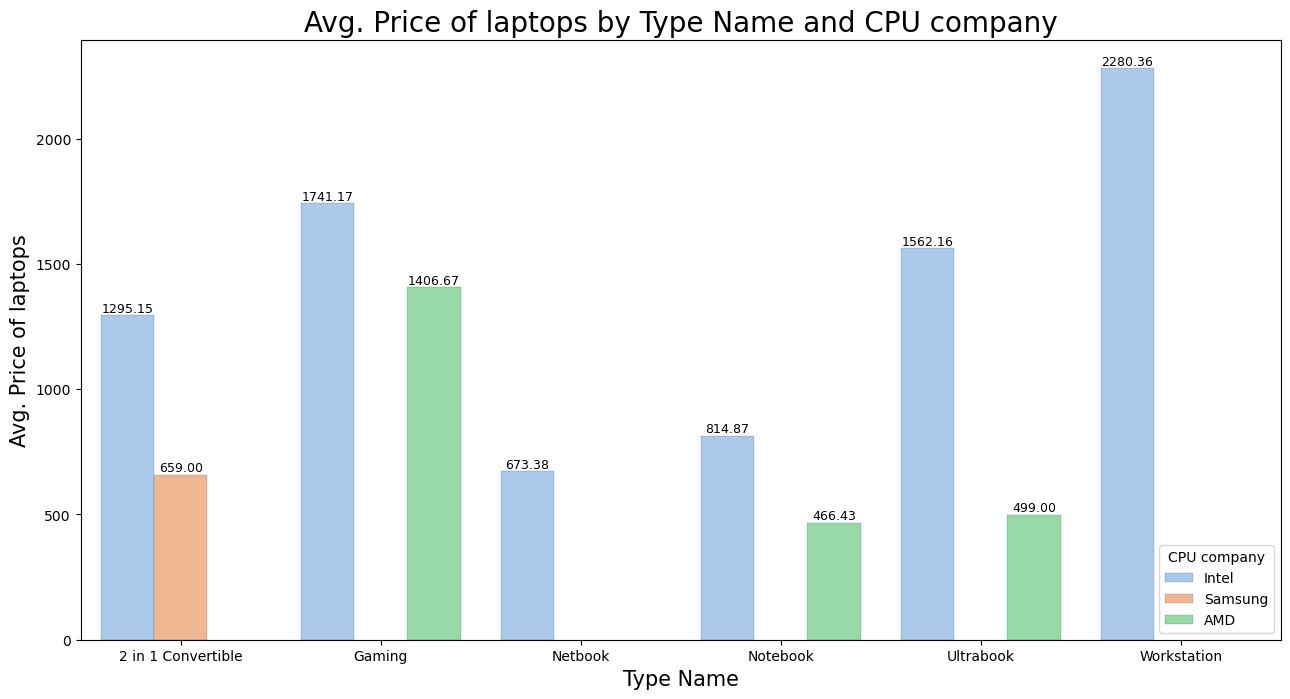

In [37]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_CPU_company = df_laptop_price_data.groupby(['Type_Name', 'CPU_company'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'CPU_company', data = avg_Price_by_Type_Name_and_CPU_company, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "CPU company", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and CPU company", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on CPU manufacturers (Intel, Samsung, AMD).

---

### 1. Overall Price Trends
- Intel-powered laptops dominate all categories and generally have the highest average prices.
- AMD-powered laptops are present in fewer categories and are usually priced lower than Intel.
- Samsung CPUs appear in very limited categories and are associated with lower-priced devices.

---

### 2. CPU Company-Based Price Insights
- Intel laptops consistently have the highest prices across all laptop types, indicating their dominance in both premium and performance segments.
- AMD laptops are more affordable and appear mainly in Gaming, Notebook, and Ultrabook categories.
- Samsung CPUs are only seen in 2-in-1 Convertibles and are priced significantly lower, suggesting usage in budget or specialized devices.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- Intel laptops (1295.15) are more expensive than Samsung-based ones (659.00).
- Shows a clear premium for Intel processors.

#### Gaming Laptops
- Intel (1741.17) is more expensive than AMD (1406.67).
- Both are high-priced, but Intel leads in premium gaming configurations.

#### Netbooks
- Only Intel laptops are present (673.38).
- Indicates limited CPU diversity in this budget category.

#### Notebooks
- Intel laptops (814.87) are significantly more expensive than AMD ones (466.43).
- Shows AMD’s presence in more budget-friendly notebook options.

#### Ultrabooks
- Intel (1562.16) dominates, with AMD (499.00) much cheaper.
- Large price gap suggests AMD ultrabooks are positioned as budget alternatives.

#### Workstations
- Only Intel laptops are present (2280.36).
- Reflects Intel’s strong dominance in high-performance professional devices.

---

### 4. Key Takeaways
- Intel is the dominant CPU provider across all laptop categories and is associated with higher prices.
- AMD offers more affordable alternatives but is less present in high-end segments like Workstations.
- Samsung CPUs have minimal presence and are limited to specific, lower-priced devices.
- CPU choice significantly influences laptop pricing, especially in mid-range and premium categories.

---

### Final Insight
The graph highlights that CPU manufacturer plays a crucial role in laptop pricing. Intel leads across all segments with higher average prices, while AMD serves as a cost-effective alternative in selected categories. Samsung CPUs have minimal impact due to their limited presence.

#### g. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`Primary_Storage_Type`**

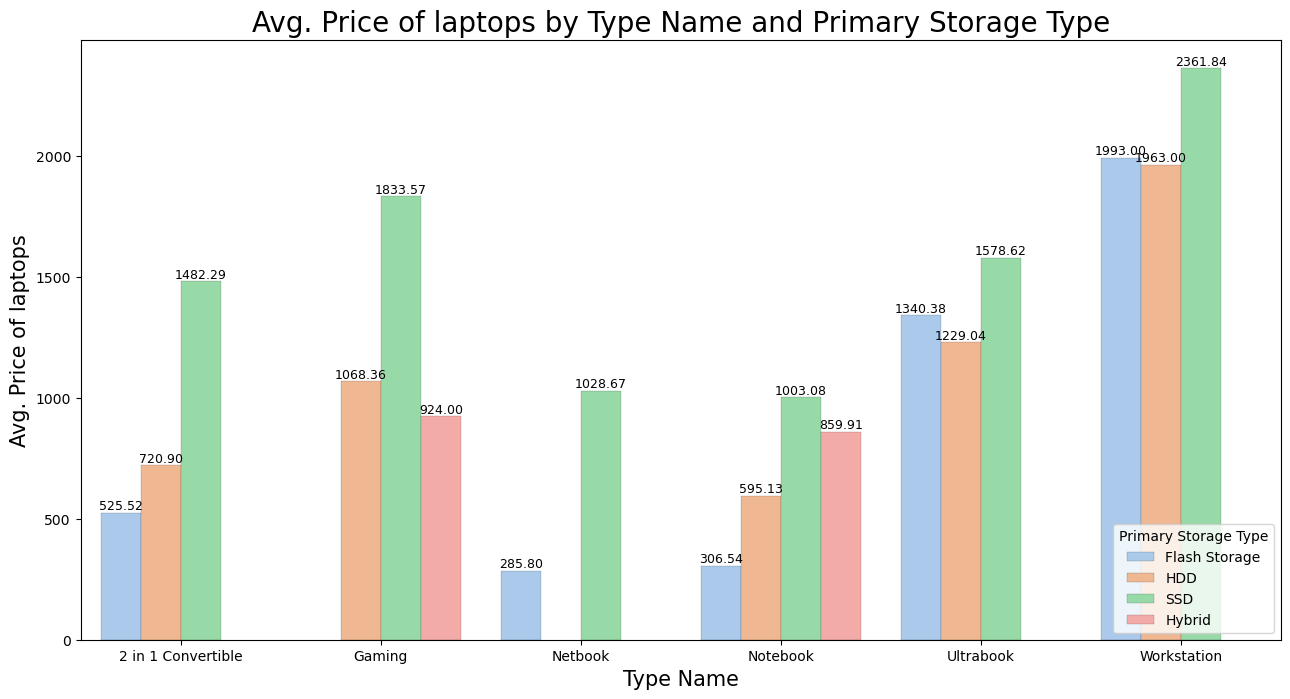

In [38]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_Primary_Storage_Type = df_laptop_price_data.groupby(['Type_Name', 'Primary_Storage_Type'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'Primary_Storage_Type', data = avg_Price_by_Type_Name_and_Primary_Storage_Type, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "Primary Storage Type", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and Primary Storage Type", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

## Interpretation of the Graph: Avg. Price of Laptops by Type and Primary Storage Type

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on primary storage types (Flash Storage, HDD, SSD, Hybrid).

---

### 1. Overall Price Trends
- Laptops with SSD storage are consistently the most expensive across all categories.
- HDD-based laptops are generally more affordable than SSD but more expensive than Flash Storage in some cases.
- Flash Storage is typically found in lower-priced or compact devices.
- Hybrid storage appears in limited categories and falls between HDD and SSD in pricing.

---

### 2. Storage Type-Based Price Insights
- SSD laptops dominate the premium segment due to faster performance and reliability.
- HDD laptops offer a balance between cost and storage capacity, making them mid-range.
- Flash Storage laptops are the cheapest, commonly used in lightweight or budget devices.
- Hybrid storage provides a mix of performance and capacity, but its presence is limited.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- SSD laptops (1482.29) are significantly more expensive than HDD (720.90) and Flash Storage (525.52).
- Shows strong preference for SSD in premium convertibles.

#### Gaming Laptops
- SSD (1833.57) leads, followed by HDD (1068.36) and Hybrid (924.00).
- Gaming laptops benefit heavily from SSD performance.

#### Netbooks
- SSD (1028.67) is much higher than Flash Storage (285.80).
- No HDD or Hybrid presence, indicating limited configurations.

#### Notebooks
- SSD (1003.08) is highest, followed by Hybrid (859.91), HDD (595.13), and Flash Storage (306.54).
- Clear price progression based on storage performance.

#### Ultrabooks
- SSD (1578.62) is highest, followed by Flash Storage (1340.38) and HDD (1229.04).
- Reflects premium design and performance expectations.

#### Workstations
- SSD (2361.84) is the most expensive overall.
- Followed by Flash Storage (1993.00) and HDD (1963.00).
- Indicates high-performance storage is critical in professional devices.

---

### 4. Key Takeaways
- SSD is the most influential factor in increasing laptop prices across all categories.
- Flash Storage is associated with budget-friendly and compact devices.
- HDD remains a mid-range option but is less dominant in premium categories.
- Hybrid storage is less common and sits between HDD and SSD in pricing.

---

### Final Insight
The graph highlights that storage type plays a major role in laptop pricing. SSD-based laptops command higher prices due to superior performance, while Flash Storage and HDD cater to budget and mid-range segments. As performance demands increase, SSD becomes the preferred choice across all laptop types.

#### h. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`Secondary_Storage_Type`**

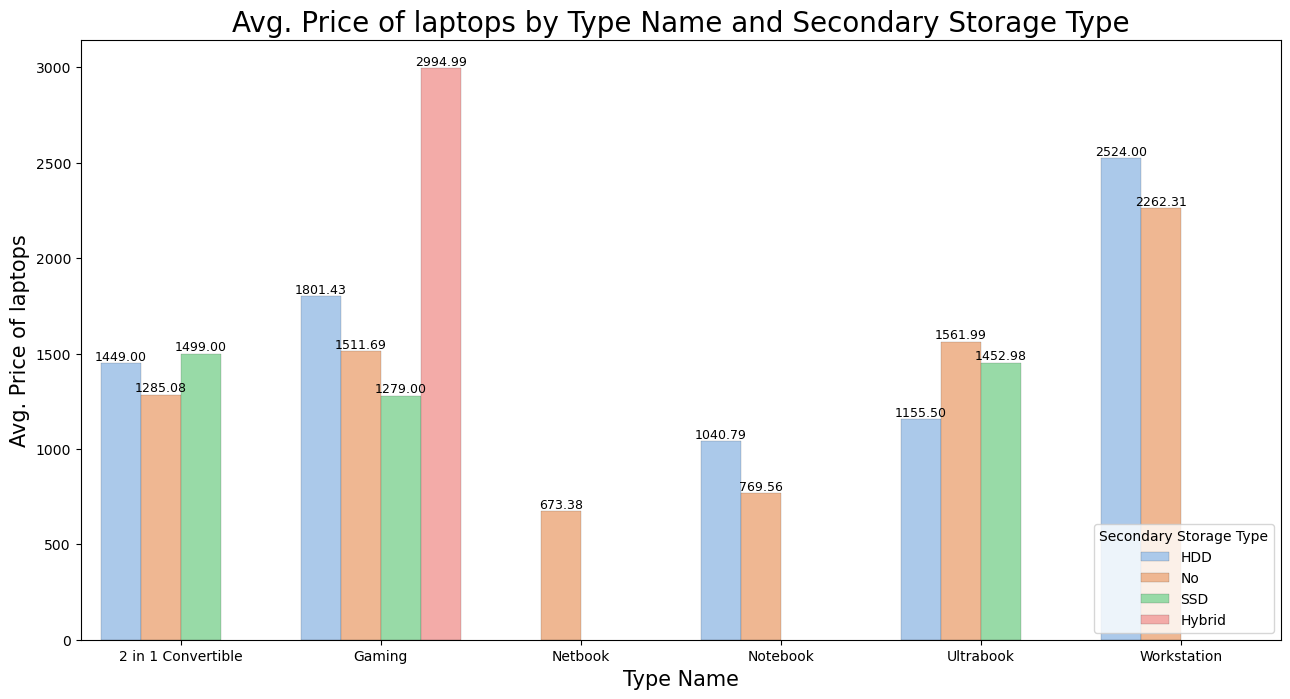

In [39]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_Secondary_Storage_Type = df_laptop_price_data.groupby(['Type_Name', 'Secondary_Storage_Type'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'Secondary_Storage_Type', data = avg_Price_by_Type_Name_and_Secondary_Storage_Type, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "Secondary Storage Type", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and Secondary Storage Type", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on secondary storage types (HDD, No Secondary Storage, SSD, Hybrid).

---

### 1. Overall Price Trends
- Laptops with secondary storage generally show higher prices, especially in premium categories.
- Hybrid and HDD secondary storage configurations tend to be associated with higher-priced laptops.
- Devices with no secondary storage are usually more affordable but vary depending on category.

---

### 2. Secondary Storage Type-Based Insights
- HDD as secondary storage is common in higher-priced configurations, especially in Workstations and Gaming laptops.
- SSD as secondary storage appears in mid-to-premium devices, offering better performance.
- Hybrid storage shows the highest price in specific cases, indicating high-end configurations.
- Laptops without secondary storage are typically more affordable but still vary depending on overall hardware.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- SSD (1499.00) is slightly more expensive than HDD (1449.00) and No secondary storage (1285.08).
- Shows moderate impact of secondary storage on pricing.

#### Gaming Laptops
- Hybrid storage (2994.99) is significantly higher than all other types.
- HDD (1801.43) and No storage (1511.69) follow, while SSD (1279.00) is lower.
- Indicates complex configurations in gaming devices.

#### Netbooks
- Only No secondary storage is present (673.38).
- Reflects limited hardware configurations.

#### Notebooks
- HDD (1040.79) is highest, followed by No storage (769.56).
- No SSD or Hybrid presence, indicating simpler configurations.

#### Ultrabooks
- No secondary storage (1561.99) is highest, followed by SSD (1452.98) and HDD (1155.50).
- Suggests ultrabooks prioritize compact design over multiple storage drives.

#### Workstations
- HDD (2524.00) is the most expensive, followed by No storage (2262.31).
- Indicates heavy storage needs in professional systems.

---

### 4. Key Takeaways
- Secondary storage adds value and increases laptop prices in many cases.
- Hybrid and HDD configurations are often linked to higher-end systems.
- Ultrabooks tend to avoid secondary storage, focusing on portability.
- Netbooks and basic Notebooks have limited or no secondary storage options.

---

### Final Insight
The graph shows that secondary storage type influences laptop pricing, but its impact varies across categories. High-performance systems like Gaming laptops and Workstations benefit more from additional storage, while lightweight devices like Ultrabooks prioritize simplicity and portability over multiple storage options.

#### i. Bar plot for Average **`Price_euros`** by **`Type_Name`** and **`GPU_company`**

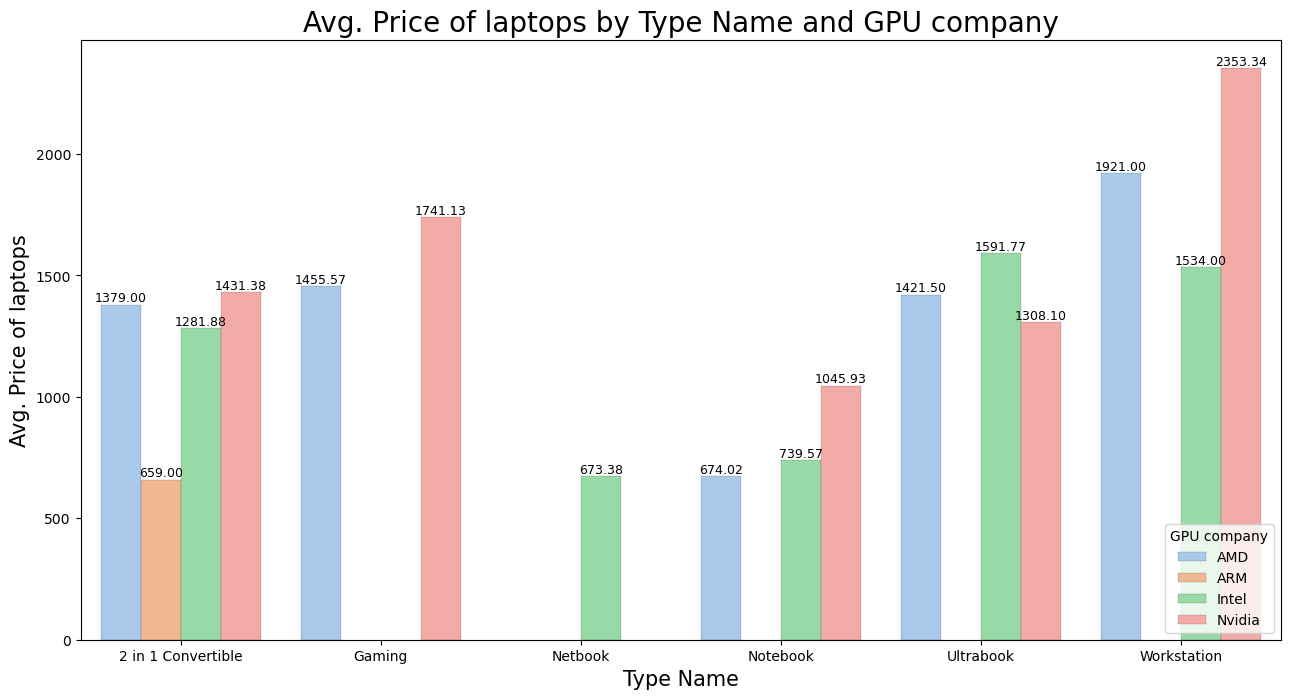

In [40]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12,6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Preparing the data for the graph
avg_Price_by_Type_Name_and_GPU_company = df_laptop_price_data.groupby(['Type_Name', 'GPU_company'])['Price_euros'].mean().reset_index()

# Plotting the graph
bars = sns.barplot(x = 'Type_Name', y = 'Price_euros', hue = 'GPU_company', data = avg_Price_by_Type_Name_and_GPU_company, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Type Name", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Avg. Price of laptops", fontsize = 15)

# Setting the size of values on x and y axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting the position of legend
plt.legend(title = "GPU company", loc = "lower right")

# Setting the title of the graph
ax.set_title("Avg. Price of laptops by Type Name and GPU company", fontsize = 20)

# Printing the values of the bars
for container in bars.containers:
    ax.bar_label(container, fmt = '%.2f', fontsize = 9)

# Displaying the graph
plt.show()

**Interpretation**

This graph compares the average prices of laptops across different type categories (2-in-1 Convertible, Gaming, Netbook, Notebook, Ultrabook, Workstation) based on GPU manufacturers (AMD, ARM, Intel, Nvidia).

---

### 1. Overall Price Trends
- Nvidia-powered laptops are generally the most expensive, especially in high-performance categories.
- AMD and Intel GPUs are present across most categories with moderate to high pricing.
- ARM-based laptops are limited in presence and are associated with lower prices.
- Workstations and Gaming laptops remain the most expensive categories overall.

---

### 2. GPU Company-Based Price Insights
- Nvidia GPUs dominate the premium segment, particularly in Gaming and Workstations.
- AMD GPUs offer competitive pricing and appear in multiple categories.
- Intel GPUs are commonly found in mid-range laptops and show moderate pricing.
- ARM GPUs are mostly limited to low-cost or specialized devices.

---

### 3. Category-Specific Observations

#### 2-in-1 Convertible
- Nvidia (1431.38) is slightly higher than AMD (1379.00) and Intel (1281.88).
- ARM (659.00) is significantly cheaper.

#### Gaming Laptops
- Nvidia (1741.13) is the most expensive, followed by AMD (1455.57).
- No Intel or ARM presence, highlighting preference for high-performance GPUs.

#### Netbooks
- Only Intel GPUs are present (673.38).
- Indicates basic graphical requirements.

#### Notebooks
- Nvidia (1045.93) is higher than Intel (739.57) and AMD (674.02).
- Shows performance-based pricing differences.

#### Ultrabooks
- Intel (1591.77) is the highest, followed by AMD (1421.50) and Nvidia (1308.10).
- Suggests efficiency-focused GPUs dominate this category.

#### Workstations
- Nvidia (2353.34) is the highest overall.
- AMD (1921.00) and Intel (1534.00) follow.
- Reflects demand for powerful GPUs in professional workloads.

---

### 4. Key Takeaways
- Nvidia GPUs significantly increase laptop prices, especially in Gaming and Workstations.
- AMD provides a balance between performance and cost across categories.
- Intel GPUs are widely used in mid-range and efficiency-focused laptops.
- ARM GPUs are limited and associated with budget-friendly devices.

---

### Final Insight
The graph shows that GPU manufacturer plays a major role in determining laptop prices. Nvidia leads in high-performance and premium segments, while AMD and Intel serve broader markets with balanced pricing. ARM remains niche with minimal influence on overall pricing trends.

### 2. Numerical-Numerical-Categorical column group.

Here we will choose combinations of Numerical and Categorical columns against **Price** column.

#### a. Scatter plot for **`Price_euro`** and **`CPU_frequency`** by **`CPU_company`**.

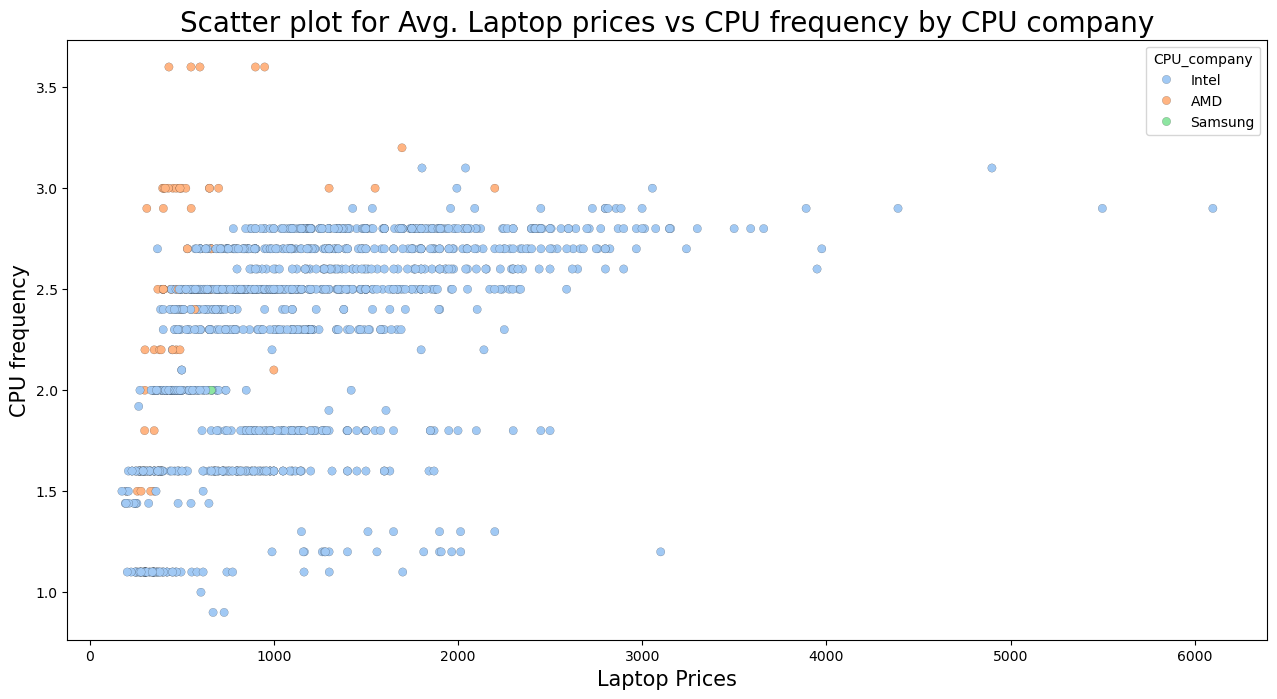

In [41]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12, 6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Plotting the graph
sns.scatterplot(x = 'Price_euros', y = 'CPU_frequency', hue = 'CPU_company', data = df_laptop_price_data, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Laptop Prices", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("CPU frequency", fontsize = 15)

# Setting the size of values on the axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting name of the title
ax.set_title("Scatter plot for Avg. Laptop prices vs CPU frequency by CPU company", fontsize = 20)

# Setting the legend
plt.legend(title = "CPU_company")

# Displaying the graph
plt.show()

**Interpretation**

This scatter plot shows the relationship between laptop prices and CPU frequency, categorized by CPU manufacturers (Intel, AMD, Samsung).

---

### 1. Overall Relationship Between Price and CPU Frequency
- There is a general positive trend where higher-priced laptops tend to have higher CPU frequencies.
- However, the relationship is not strictly linear, as laptops with similar frequencies can have very different prices.
- This indicates that factors beyond CPU frequency, such as GPU, storage, and build quality, also influence price.

---

### 2. Intel-Based Laptops
- Intel dominates the dataset with the highest number of data points.
- Prices range widely from low to very high values.
- CPU frequencies mostly cluster between 1.5 GHz and 3.0 GHz.
- High-end Intel laptops reach prices above 5000 while maintaining frequencies around 2.5 to 3.1 GHz.
- Shows that Intel is used across all segments from budget to premium.

---

### 3. AMD-Based Laptops
- AMD laptops are fewer in number compared to Intel.
- Frequencies are generally higher, often between 2.0 GHz and 3.6 GHz.
- Prices are mostly in the mid-range, with fewer extremely high-priced models.
- Indicates AMD focuses on performance at relatively lower price points.

---

### 4. Samsung-Based Laptops
- Very limited data points for Samsung.
- Frequencies are around 2.0 GHz.
- Prices are relatively low, indicating presence in budget or specialized devices.

---

### 5. Key Observations
- High price does not always mean significantly higher CPU frequency.
- Many expensive laptops have similar CPU frequencies as mid-range ones, suggesting premium pricing comes from other features.
- AMD offers higher frequencies at competitive prices.
- Intel provides a wide range of options across all price segments.

---

### Final Insight
The graph shows that while CPU frequency contributes to laptop pricing, it is not the sole determining factor. Premium laptops often justify higher prices through additional features beyond CPU performance, while AMD provides strong frequency performance at mid-range prices and Intel dominates across all segments.

#### b. Scatter plot for **`Price_euro`** and **`Primary_Storage`** by **`Primary_Storage_Type`**.

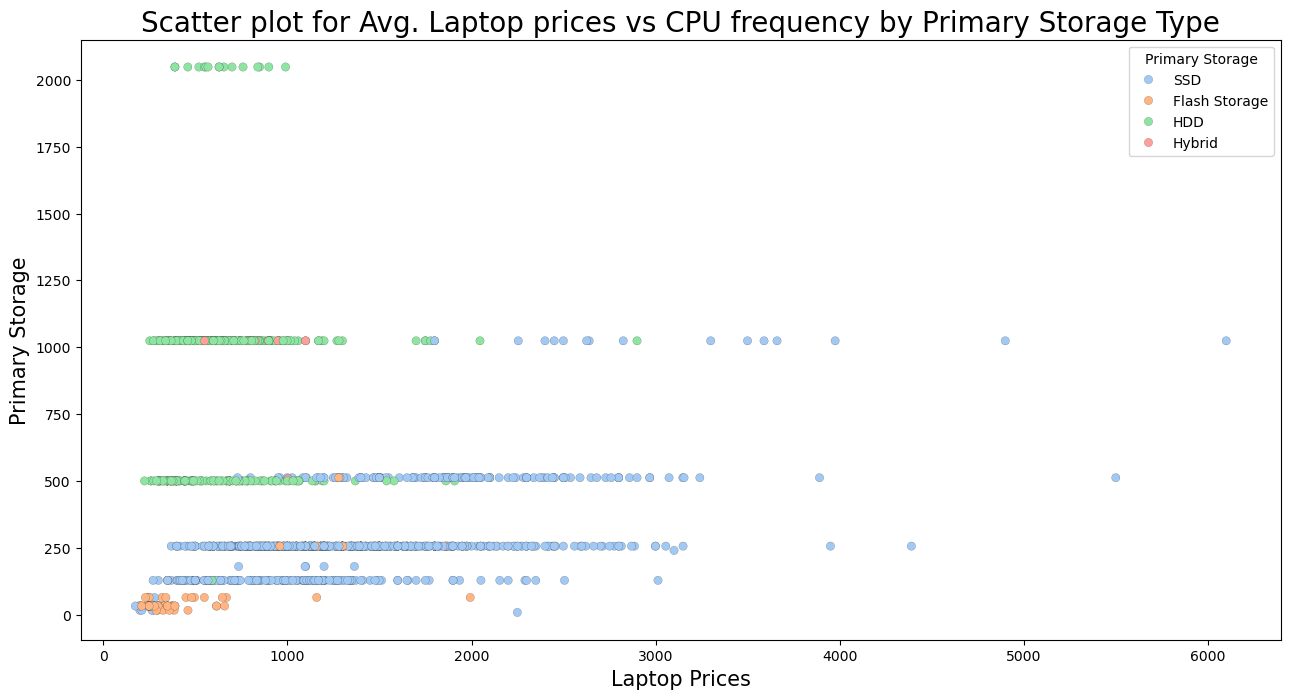

In [42]:
# Setting the figure for the graph
fig = plt.figure(figsize = (12, 6))

# Setting the axes for the graph
ax = fig.add_axes([0,0,1,1])

# Plotting the graph
sns.scatterplot(x = 'Price_euros', y = 'Primary_Storage', hue = 'Primary_Storage_Type', data = df_laptop_price_data, palette = 'pastel', edgecolor = 'black', linewidth = 0.1)

# Setting the name of x axis
ax.set_xlabel("Laptop Prices", fontsize = 15)

# Setting the name of y axis
ax.set_ylabel("Primary Storage", fontsize = 15)

# Setting the size of values on the axis
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Setting name of the title
ax.set_title("Scatter plot for Avg. Laptop prices vs CPU frequency by Primary Storage Type", fontsize = 20)

# Setting the legend
plt.legend(title = "Primary Storage")

# Displaying the graph
plt.show()

**Interpretation**

This scatter plot shows the relationship between laptop prices and CPU frequency, categorized by primary storage types (SSD, Flash Storage, HDD, Hybrid).

---

### 1. Overall Relationship Between Price and CPU Frequency
- There is no strong direct relationship between CPU frequency and laptop price.
- Laptops with similar CPU frequencies are spread across a wide range of prices.
- This suggests that storage type and other hardware components significantly influence pricing.

---

### 2. SSD-Based Laptops
- SSD laptops dominate the higher price ranges.
- They are widely spread across all CPU frequencies, especially between 1.5 GHz and 3.0 GHz.
- Many high-priced laptops above 3000 use SSD storage.
- Indicates SSD is a key factor in premium devices.

---

### 3. HDD-Based Laptops
- HDD laptops are mostly concentrated in mid-range prices.
- They appear commonly around standard storage sizes such as 500 GB and 1000 GB.
- Even with similar CPU frequencies, HDD laptops are generally cheaper than SSD ones.
- Suggests HDD is used for cost-effective storage solutions.

---

### 4. Flash Storage Laptops
- Flash storage laptops are clustered at lower price ranges.
- Typically associated with smaller storage capacities and lower CPU frequencies.
- Mostly found in budget and lightweight devices.

---

### 5. Hybrid Storage Laptops
- Hybrid storage appears in limited data points.
- Prices are generally mid to high range.
- Combines features of HDD and SSD, offering balanced performance.

---

### 6. Key Observations
- Storage type has a stronger influence on price than CPU frequency alone.
- SSD laptops consistently appear in higher price segments regardless of CPU frequency.
- Budget laptops tend to use Flash Storage or HDD.
- High storage capacity does not always mean higher CPU frequency.

---

### Final Insight
The graph highlights that while CPU frequency contributes to performance, storage type plays a more significant role in determining laptop pricing. SSD-based systems dominate the premium market, while HDD and Flash Storage are more common in budget and mid-range devices.

# Step 4: Preparing the data for Machine Learning

## 1. Outlier Treatment

We will first make a **Statistical description table** of all the numerical columns of the dataframe, then we will see the difference between **mean** and **median** of each column, which will tell us whether **outliers** are present in a particular column or not. Then treat them accordingly.

In [43]:
# Using the 'describe' method
df_laptop_price_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Screen_Size,1275.0,15.022902,1.429470,10.10,14.0,15.60,15.60,18.4
Ram,1275.0,8.440784,5.097809,2.00,4.0,8.00,8.00,64.0
Weight,1275.0,2.040525,0.669196,0.69,1.5,2.04,2.31,4.7
Price_euros,1275.0,1134.969059,700.752504,174.00,609.0,989.00,1496.50,6099.0
Screen_Width,1275.0,1900.043922,493.346186,1366.00,1920.0,1920.00,1920.00,3840.0
Screen_Height,1275.0,1073.904314,283.883940,768.00,1080.0,1080.00,1080.00,2160.0
CPU_frequency,1275.0,2.302980,0.503846,0.90,2.0,2.50,2.70,3.6
Primary_Storage,1275.0,444.517647,365.537726,8.00,256.0,256.00,512.00,2048.0
Secondary_Storage,1275.0,176.069020,415.960655,0.00,0.0,0.00,0.00,2048.0


**Interpretation**

We can see that in the following columns:
**`Price_euros`**
**`Primary_Storage`**
**`Secondary_Storage`**

The difference between their **mean** and **median** is significant which means that there can be outliers present in them.

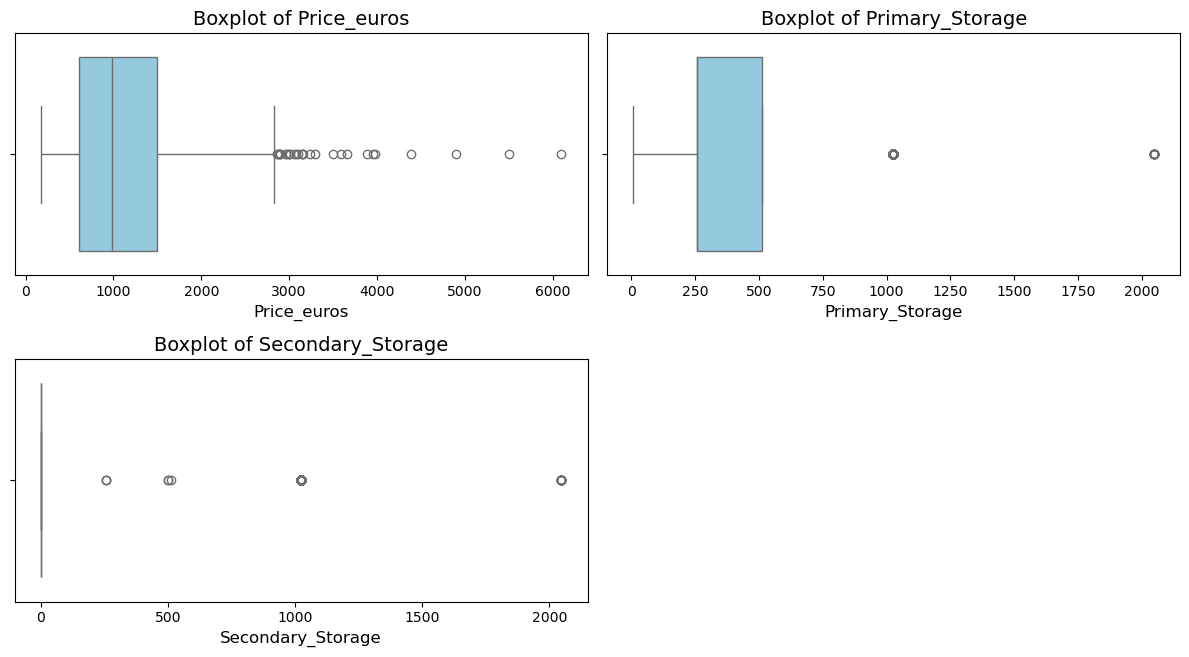

In [44]:
# Columns with outliers
outlier_cols = [
    'Price_euros',
    'Primary_Storage',
    'Secondary_Storage'
]

# Setting up the figure
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 16))
axes = axes.flatten()

# Plot boxplots for each column
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df_laptop_price_data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].tick_params(axis='x', labelsize=10)

# Remove the empty subplot if number of columns < grid size
for j in range(len(outlier_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation**

As we can see clearly see here that outliers are present in these columns from these Box plots and we will treat them but we will leave the outliers in **`Secondary_Storage`** as it is.

#### Treating the outliers

In [45]:
# Select numerical columns where outliers might be a problem
numerical_cols_for_outliers = ['Price_euros', 'Primary_Storage']

# For loop for iterating through these columns
for col in numerical_cols_for_outliers:
    # Finding Quartile 1
    Q1 = df_laptop_price_data[col].quantile(0.25)

    # Finding Quartile 3
    Q3 = df_laptop_price_data[col].quantile(0.75)

    # Finding the Interquartile range
    IQR = Q3 - Q1

    # Finding the Lower bound of the column
    lower_bound = Q1 - 1.5 * IQR

    # Finding the Upper bound of the column 
    upper_bound = Q3 + 1.5 * IQR

    # Capping the outliers
    df_laptop_price_data[col] = np.clip(df_laptop_price_data[col], lower_bound, upper_bound)

print("Outlier treatment complete.")

Outlier treatment complete.


#### Visualizing the **Outliers** in these columns again to check

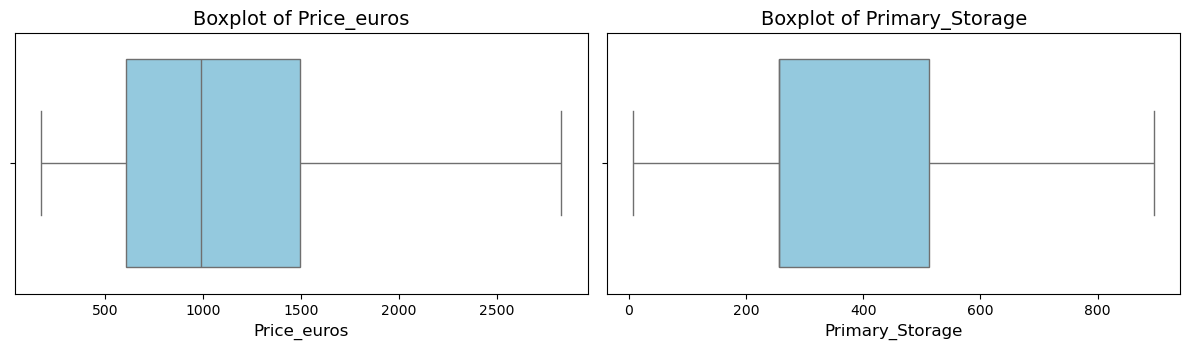

In [46]:
# Columns with outliers
outlier_cols = [
    'Price_euros',
    'Primary_Storage'
]

# Setting up the figure
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 16))
axes = axes.flatten()

# Plot boxplots for each column
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df_laptop_price_data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f"Boxplot of {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].tick_params(axis='x', labelsize=10)

# Remove the empty subplot if number of columns < grid size
for j in range(len(outlier_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interpretation**

As we can see in all the columns the outliers are treated completely and now no outliers are present in them.

## 2. Scaling and Encoding

First we will we split the dataset into **Dependent** and **Independent** variables.

In [47]:
df_laptop_price_data_unprocessed = df_laptop_price_data.copy()

### a. Encoding

We will use **Target Encoder** for high cardinality columns and **Label Encoder** for normal ones.

In [48]:
# Checking categorical columns with high cardinality
for cols in df_laptop_price_data.select_dtypes(include = 'object').columns:
  print(f"for column {cols}", df_laptop_price_data[cols].nunique())

for column Company 19
for column Product 618
for column Type_Name 6
for column OS 9
for column Screen_Definition 4
for column Touchscreen 2
for column IPS_panel 2
for column Retina_Display 2
for column CPU_company 3
for column CPU_model 93
for column Primary_Storage_Type 4
for column Secondary_Storage_Type 4
for column GPU_company 4
for column GPU_model 110


In [49]:
# Identifying categorical columns with many unique values
high_cardinality_cols = ['Product', 'CPU_model', 'GPU_model']

# Group rare categories into 'Other'
for col in high_cardinality_cols:
    # Calculate the frequency of each category
    value_counts = df_laptop_price_data[col].value_counts()

    # Identify categories that appear less than a threshold (e.g., 10 times)
    rare_categories = value_counts[value_counts < 20].index

    # Replace rare categories with 'Other'
    df_laptop_price_data[col] = df_laptop_price_data[col].replace(rare_categories, 'Other')

print("Rare categories have been grouped.")

Rare categories have been grouped.


In [50]:
# We will use Target Encoding for high-cardinality features.

# Columns to target encode
target_encode_cols = ['Product', 'CPU_model', 'GPU_model']

# Using target encoding for high cardinality categorical columns
for col in target_encode_cols:
    # Calculate the mean salary for each category
    target_mean = df_laptop_price_data.groupby(col)['Price_euros'].mean()

    # Replace the category with its calculated mean salary
    df_laptop_price_data[col] = df_laptop_price_data[col].map(target_mean)

# Using LabelEncoder for the normal categorical columns
le = LabelEncoder()
df_laptop_price_data['Company'] = le.fit_transform(df_laptop_price_data['Company'])
df_laptop_price_data['Type_Name'] = le.fit_transform(df_laptop_price_data['Type_Name'])
df_laptop_price_data['OS'] = le.fit_transform(df_laptop_price_data['OS'])
df_laptop_price_data['Screen_Definition'] = le.fit_transform(df_laptop_price_data['Screen_Definition'])
df_laptop_price_data['Touchscreen'] = le.fit_transform(df_laptop_price_data['Touchscreen'])
df_laptop_price_data['IPS_panel'] = le.fit_transform(df_laptop_price_data['IPS_panel'])
df_laptop_price_data['Retina_Display'] = le.fit_transform(df_laptop_price_data['Retina_Display'])
df_laptop_price_data['CPU_company'] = le.fit_transform(df_laptop_price_data['CPU_company'])
df_laptop_price_data['Primary_Storage_Type'] = le.fit_transform(df_laptop_price_data['Primary_Storage_Type'])
df_laptop_price_data['Secondary_Storage_Type'] = le.fit_transform(df_laptop_price_data['Secondary_Storage_Type'])
df_laptop_price_data['GPU_company'] = le.fit_transform(df_laptop_price_data['GPU_company'])

print("Target and Label Encoding complete.")
df_laptop_price_data.head()

Target and Label Encoding complete.


,Company,Product,Type_Name,Screen_Size,Ram,OS,Weight,Price_euros,Screen_Definition,Screen_Width,Screen_Height,Touchscreen,IPS_panel,Retina_Display,CPU_company,CPU_frequency,CPU_model,Primary_Storage,Secondary_Storage,Primary_Storage_Type,Secondary_Storage_Type,GPU_company,GPU_model
0,1,1130.030409,4,13.3,8,8,1.37,1339.69,3,2560,1600,0,1,1,1,2.3,1161.554362,128,0,3,2,2,1163.830674
1,1,1130.030409,4,13.3,8,8,1.34,898.94,3,1440,900,0,0,0,1,1.8,1161.554362,128,0,0,2,2,1163.830674
2,7,467.602381,3,15.6,8,4,1.86,575.00,1,1920,1080,0,0,0,1,2.5,919.318083,256,0,3,2,2,1146.058530
3,1,1130.030409,4,15.4,16,8,1.83,2537.45,3,2880,1800,0,1,1,1,2.7,1161.554362,512,0,3,2,0,1163.830674
4,1,1130.030409,4,13.3,8,8,1.37,1803.60,3,2560,1600,0,1,1,1,3.1,1161.554362,256,0,3,2,2,1163.830674


In [51]:
# Sepearting X and y
X = df_laptop_price_data.drop(columns = 'Price_euros', axis = 1)
y = df_laptop_price_data['Price_euros']

# Making y a dataframe again
y = pd.DataFrame(data = y, columns = ['Price_euros'])

In [52]:
# Checking X
X.head()

,Company,Product,Type_Name,Screen_Size,Ram,OS,Weight,Screen_Definition,Screen_Width,Screen_Height,Touchscreen,IPS_panel,Retina_Display,CPU_company,CPU_frequency,CPU_model,Primary_Storage,Secondary_Storage,Primary_Storage_Type,Secondary_Storage_Type,GPU_company,GPU_model
0,1,1130.030409,4,13.3,8,8,1.37,3,2560,1600,0,1,1,1,2.3,1161.554362,128,0,3,2,2,1163.830674
1,1,1130.030409,4,13.3,8,8,1.34,3,1440,900,0,0,0,1,1.8,1161.554362,128,0,0,2,2,1163.830674
2,7,467.602381,3,15.6,8,4,1.86,1,1920,1080,0,0,0,1,2.5,919.318083,256,0,3,2,2,1146.058530
3,1,1130.030409,4,15.4,16,8,1.83,3,2880,1800,0,1,1,1,2.7,1161.554362,512,0,3,2,0,1163.830674
4,1,1130.030409,4,13.3,8,8,1.37,3,2560,1600,0,1,1,1,3.1,1161.554362,256,0,3,2,2,1163.830674


In [53]:
# Checking y
y.head()

,Price_euros
0,1339.69
1,898.94
2,575.00
3,2537.45
4,1803.60


### b. Scaling

We will use **Standard Scaler**

In [54]:
# Seperating the Numerical columns
num_cols = X.select_dtypes(include = np.number)

# Initializing the StandardScaler
ss = StandardScaler()

for col in num_cols:
  X[col] = ss.fit_transform(X[[col]])

In [55]:
# Checking the num_cols
num_cols.head()

,Company,Product,Type_Name,Screen_Size,Ram,OS,Weight,Screen_Definition,Screen_Width,Screen_Height,Touchscreen,IPS_panel,Retina_Display,CPU_company,CPU_frequency,CPU_model,Primary_Storage,Secondary_Storage,Primary_Storage_Type,Secondary_Storage_Type,GPU_company,GPU_model
0,1,1130.030409,4,13.3,8,8,1.37,3,2560,1600,0,1,1,1,2.3,1161.554362,128,0,3,2,2,1163.830674
1,1,1130.030409,4,13.3,8,8,1.34,3,1440,900,0,0,0,1,1.8,1161.554362,128,0,0,2,2,1163.830674
2,7,467.602381,3,15.6,8,4,1.86,1,1920,1080,0,0,0,1,2.5,919.318083,256,0,3,2,2,1146.058530
3,1,1130.030409,4,15.4,16,8,1.83,3,2880,1800,0,1,1,1,2.7,1161.554362,512,0,3,2,0,1163.830674
4,1,1130.030409,4,13.3,8,8,1.37,3,2560,1600,0,1,1,1,3.1,1161.554362,256,0,3,2,2,1163.830674


**Interpretation**

Now we have the prepared dataset

## 3. Splitting the dataset into **Training** and **Testing** portion

In [56]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

**Interpretation**

Now our dataset is split on 70 30 proportion for training and testing data respectively

# Step 5: Training and Testing the model

## 1. Model Selection

In [57]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=1, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=1),
    "xgb_model": xgb.XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8, random_state=1, n_jobs=-1),
    "lgb_model": lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=-1,
                              subsample=0.8, colsample_bytree=0.8, random_state=1, n_jobs=-1),
    "cat_model": CatBoostRegressor(iterations=300, learning_rate=0.1, depth=6,
                                  random_state=1, verbose=0)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 282
[LightGBM] [Info] Number of data points in the train set: 892, number of used features: 21
[LightGBM] [Info] Start training from score 1095.229024
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [58]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='R² Score', ascending=False)

,Model,MAE,RMSE,R² Score
6,xgb_model,168.858093,243.803047,0.857273
8,cat_model,174.929684,250.378835,0.849470
7,lgb_model,175.727075,252.431315,0.846992
4,Random Forest,179.815197,258.479479,0.839572
5,Gradient Boosting,191.537887,265.135218,0.831204
3,Decision Tree,227.888760,344.292257,0.715369
1,Ridge Regression,257.620993,354.277803,0.698620
2,Lasso Regression,257.623204,354.308318,0.698568
0,Linear Regression,257.629695,354.312170,0.698561


**Interpretation**

- **XGBoost model** achieved the highest R² Score (**0.857273**) with the lowest RMSE (**243.803047**) and MAE (**168.858093**), making it the best performing model overall.
- Then **CatBoost model** and **light gradient boost model** have near equal R² Scores i.e. **0.849470** and **0.846992**, making them second best, followed by **Random Forest model** and **Gradient Boosting model** which have near equal R² Scores i.e. **0.839572** and **0.831204**.
- Then we have all the other models with R² Scores less than **0.72**.

**Conclusion**:  
- The best candidate from these we can say is **XGBoost model** as it provides the most accurate predictions.  
- So for final deployment, **XGBoost model** would be recommended due to their higher predictive power an robustness.

## 2. Training the selected model

In [59]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initializing the model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Training the model
xgb_model.fit(X_train, y_train)

# Predicting on the test set
y_pred = xgb_model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost MAE: {mae:.6f}")
print(f"XGBoost RMSE: {rmse:.6f}")
print(f"XGBoost R² Score: {r2:.6f}")

XGBoost MAE: 172.146820
XGBoost RMSE: 252.134443
XGBoost R² Score: 0.847352


### &#8594; Hyperparameter tuning for XGBoost Regressor

In [60]:
# Initializing the model
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Defining parameter distributions
param_dist = {
    'n_estimators': np.arange(100, 500, 50),
    'learning_rate': np.linspace(0.01, 0.3, 30),
    'max_depth': np.arange(3, 12),
    'min_child_weight': np.arange(1, 10),
    'subsample': np.linspace(0.6, 1.0, 10),
    'colsample_bytree': np.linspace(0.6, 1.0, 10),
    'gamma': np.linspace(0, 0.5, 10),
    'reg_alpha': np.linspace(0, 1, 10),
    'reg_lambda': np.linspace(0.5, 2, 10)
}

# Initializing RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,          # number of random combinations to try
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Training the model
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': array([0.6 ..., 1. ]), 'gamma': array([0. ..., 0.5 ]), 'learning_rate': array([0.01, ..., 0.29, 0.3 ]), 'max_depth': array([ 3, 4..., 9, 10, 11]), ...}"
,n_iter,50
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [61]:
# Best parameters and score
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_

print("Best Parameters (RandomizedSearch):", best_params_random)
print("Best Cross-Validation R² Score (RandomizedSearch):", best_score_random)

Best Parameters (RandomizedSearch): {'subsample': 0.7777777777777778, 'reg_lambda': 0.6666666666666666, 'reg_alpha': 0.0, 'n_estimators': 350, 'min_child_weight': 7, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.1111111111111111, 'colsample_bytree': 0.6888888888888889}
Best Cross-Validation R² Score (RandomizedSearch): 0.8565042853355408


In [62]:
# Using the best model
best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost MAE: {mae:.6f}")
print(f"XGBoost RMSE: {rmse:.6f}")
print(f"XGBoost R² Score: {r2:.6f}")

XGBoost MAE: 164.059677
XGBoost RMSE: 240.709587
XGBoost R² Score: 0.860872


**Interpretation**

#### **1. Best Parameters**
The RandomizedSearchCV optimization selected the following hyperparameters (available in `random_search.best_params_`):

- **`n_estimators: 350`** → The model uses 350 boosting rounds (trees). A higher number of trees allows the model to learn more complex patterns, but also increases training time.

- **`learning_rate: 0.03`** → A relatively low learning rate ensures that each tree contributes small adjustments. This improves generalization and reduces the risk of overfitting, especially when paired with more trees.

- **`max_depth: 8`** → Trees are moderately deep, allowing the model to capture complex, non-linear relationships in the data without becoming overly complex.

- **`min_child_weight: 7`** → This higher value makes the model more conservative by requiring more samples in a leaf node, helping to reduce overfitting.

- **`subsample: 0.78`** → Around 78% of the training data is randomly sampled for each tree. This introduces randomness and improves generalization.

- **`colsample_bytree: 0.69`** → About 69% of features are used per tree, further reducing overfitting and improving robustness.

- **`gamma: 0.11`** → A small regularization term that prevents unnecessary splits unless they provide a meaningful improvement.

- **`reg_alpha: 0.0`** → No L1 regularization is applied, meaning the model does not enforce sparsity in feature weights.

- **`reg_lambda: 0.67`** → A moderate L2 regularization term that helps control model complexity and prevents overfitting.

Overall, these parameters indicate a **well-regularized and moderately complex model**, balancing learning capacity with generalization.

---

#### **2. Cross-Validation Performance**
- **Best Cross-Validation R² Score:** `0.8565`  

This means the model explains approximately **85.65% of the variance** in the training data across the 5 cross-validation folds.

This suggests:
- The model captures a **strong portion of the underlying patterns** in the data.
- There is **good consistency across folds**, indicating stable performance.
- The relationship is likely **non-linear and moderately complex**.

---

#### **3. Test Set Evaluation**
- **Test MAE (Mean Absolute Error):** `164.059677`  
  On average, the model’s predictions deviate from the true values by about **164.06 units**.

- **Test RMSE (Root Mean Squared Error):** `240.709587`  
  The typical prediction error magnitude is around **240.71 units**. Since RMSE is significantly higher than MAE, this indicates the presence of **some larger prediction errors (outliers)**.

- **Test R² Score:** `0.860872`  
  The model explains approximately **86.09% of the variance** in the unseen test data.

---

### **Overall Conclusion**

The XGBoost model demonstrates **strong and reliable performance**:

- R² scores (~0.86) indicate that the model captures **most of the variance** in the dataset.
- The similarity between cross-validation and test R² scores suggests **good generalization** with minimal overfitting.
- Regularization parameters (`subsample`, `colsample_bytree`, `min_child_weight`, `reg_lambda`) help maintain a balance between bias and variance.
- The difference between RMSE and MAE indicates **some sensitivity to outliers or large prediction errors**.

Overall, this configuration provides a **robust, well-balanced model** suitable for capturing **complex, non-linear relationships** in the data.

## 3. Feature Selection

In [63]:
# Get feature names
feature_names = X_train.columns

# Get feature importances from the trained XGBoost model
importances = best_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Add absolute importance (optional, same as importance here but kept for consistency)
importance_df['Absolute Importance'] = np.abs(importance_df['Importance'])

# Sort by importance
top_features = importance_df.sort_values(
    by='Absolute Importance',
    ascending=False
).head(15)

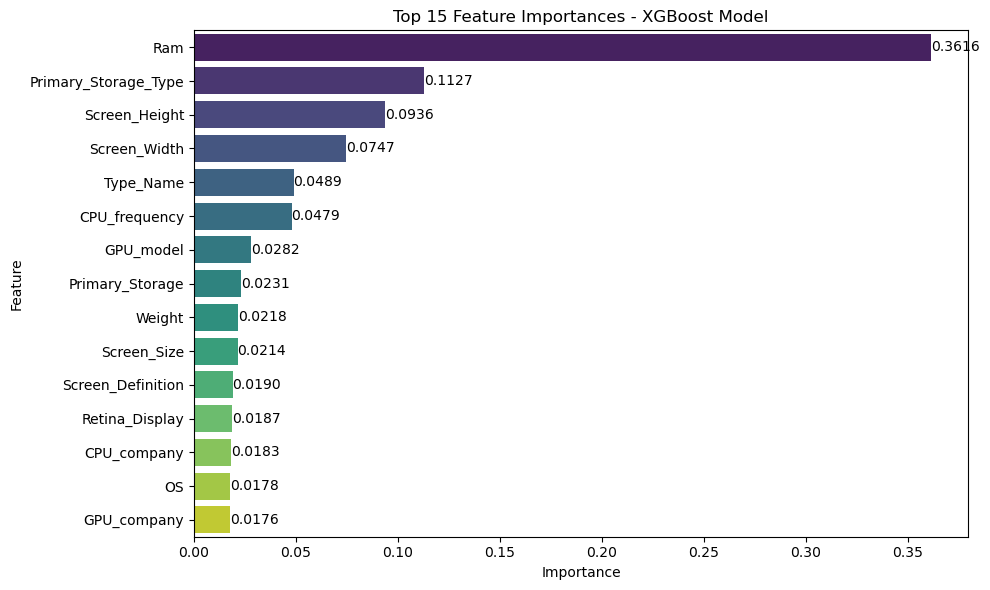

In [64]:
# Visualizing XGBoost model's feature's importance

plt.figure(figsize=(10,6))

bars = sns.barplot(
    x='Absolute Importance',
    y='Feature',
    data=top_features,
    palette='viridis'
)

plt.title("Top 15 Feature Importances - XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Add value labels on bars
for container in bars.containers:
    plt.bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()

**Interpretation**

We can see here that the following columns have **Strong Importance** on the model which are **`Ram`, `Primary_Storage_Type`, `Screen_Height`, `Screen_Width`, `Type_Name`, `CPU_frequency`, `GPU_model`, `Primary_Storage`, `Weight`, `Screen_Size` and `Screen_Definition`**.

So now we will Train and test the model on these features only to see if the accuracy improves even more.

## 4. Building the Final Model

In [65]:
# Select top 54 most important features
selected_features = ['Ram', 'Primary_Storage_Type', 'Screen_Height', 'Screen_Width', 'Type_Name', 'CPU_frequency', 'GPU_model', 'Primary_Storage',
                     'Weight', 'Screen_Size', 'Screen_Definition']

X_selected = df_laptop_price_data_unprocessed[selected_features]

In [66]:
X_selected.head(3)

,Ram,Primary_Storage_Type,Screen_Height,Screen_Width,Type_Name,CPU_frequency,GPU_model,Primary_Storage,Weight,Screen_Size,Screen_Definition
0,8,SSD,1600,2560,Ultrabook,2.3,Iris Plus Graphics 640,128,1.37,13.3,Standard
1,8,Flash Storage,900,1440,Ultrabook,1.8,HD Graphics 6000,128,1.34,13.3,Standard
2,8,SSD,1080,1920,Notebook,2.5,HD Graphics 620,256,1.86,15.6,Full HD


In [67]:
# We will use Target Encoding for high-cardinality features.

# Columns to target encode
target_encode_cols = ['GPU_model']

for col in target_encode_cols:
    target_mean = df_laptop_price_data_unprocessed.groupby(col)['Price_euros'].mean()
    X_selected[col] = df_laptop_price_data_unprocessed[col].map(target_mean)

# Using LabelEncoder for the normal categorical columns
label_encoders = {}
for col in ['Primary_Storage_Type', 'Type_Name', 'Screen_Definition']:
    le = LabelEncoder()
    X_selected[col] = le.fit_transform(X_selected[col])
    label_encoders[col] = le

print("Target and Label Encoding complete.")
X_selected.head()

Target and Label Encoding complete.


,Ram,Primary_Storage_Type,Screen_Height,Screen_Width,Type_Name,CPU_frequency,GPU_model,Primary_Storage,Weight,Screen_Size,Screen_Definition
0,8,3,1600,2560,4,2.3,1764.01125,128,1.37,13.3,3
1,8,0,900,1440,4,1.8,1022.72800,128,1.34,13.3,3
2,8,3,1080,1920,3,2.5,1146.05853,256,1.86,15.6,1
3,16,3,1800,2880,4,2.7,2537.45000,512,1.83,15.4,3
4,8,3,1600,2560,4,3.1,1921.80000,256,1.37,13.3,3


In [68]:
# Seperating the Numerical columns
num_cols = X_selected.select_dtypes(include = np.number)

scalers = {}

for col in num_cols:
    ss = StandardScaler()
    X_selected[col] = ss.fit_transform(X_selected[[col]])
    scalers[col] = ss

In [69]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)

# Initialize the model with best parameters from RandomizedSearchCV
final_xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=350,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=7,
    subsample=0.7777777777777778,
    colsample_bytree=0.6888888888888889,
    gamma=0.1111111111111111,
    reg_alpha=0.0,
    reg_lambda=0.6666666666666666,
    random_state=42,
    tree_method='hist'   # faster training (optional but recommended)
)

# Training the model
final_xgb_model.fit(X_train, y_train)

# Predicting on the test set
y_pred = final_xgb_model.predict(X_test)

# Evaluating the model
print("MAE:", mean_absolute_error(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

print("R² Score:", r2_score(y_test, y_pred))

MAE: 152.571533203125
RMSE: 215.5467249229271
R² Score: 0.8873939514160156


**Interpretation**

We can see here that with these limited features the R² Score has increased a bit rather than decreasing.

Therefore this will be the final model for deployment.

In [70]:
# Exporting the models
import joblib
joblib.dump(final_xgb_model, "XGB_model.pkl")

joblib.dump(scalers, "Standard_scalers.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")   # dict of encoders
joblib.dump(target_mean.to_dict(), "target_means.pkl")  # GPU mean encoding

['target_means.pkl']